In [9]:
import numpy as np
import pandas as pd
from statsmodels.stats.weightstats import DescrStatsW

def standardize(exposure:pd.DataFrame,capital:pd.Series):
    """利用市值加权（only均值）"""
    w_obj = DescrStatsW(exposure,weights=capital)
    w_mu = w_obj.mean
    w_std = exposure.std()
    return (exposure - w_mu) / w_std

class CrossSection():
    """
    base_data:record shares'basics
    industry_expo:0/1
    style_expo:float
    """

    def __init__(self,base_data:pd.DataFrame,industry_expo=pd.DataFrame(),style_expo=pd.DataFrame()):
        self.N = base_data.shape[0]
        self.P = industry_expo.shape[1]
        self.Q = style_expo.shape[1]
        self.date = base_data.tradedate[0]
        self.capital = base_data.capital
        self.ret = base_data.ret
        
        self.style_expo = standardize(style_expo,self.capital).values
        self.industry_expo = industry_expo.values
        self.W = np.diag(self.capital / self.capital.sum()) # already inversed
        self.country_expo = np.array(self.N*[[1]])

        print('\rCross Section Regression, ' + 'Date: ' + self.date  + ', ' + \
              str(self.N) + ' Stocks, ' + str(self.P) + ' Industry Facotrs, ' +  str(self.Q) + ' Style Facotrs', end = '')

    

    def reg(self):
        """横截面回归R=XF+e
        控制异方差和多重共线性问题"""
        industry_cap = self.capital @ self.industry_expo
        X = np.matrix(np.hstack([self.country_expo,self.industry_expo,self.style_expo])) # N*(1+P+Q)

        C = np.eye((1+self.P+self.Q))
        C[self.P,1:(1+self.P)] = industry_cap / industry_cap[-1]
        C = np.delete(C,self.P,axis=1) # (P+Q+1)*(P+Q)
        X_trans = X @ C # N*(P+Q)
        pure_factor_weight = C @ np.linalg.inv(X_trans.T @ self.W @ X_trans) @ X_trans.T @ self.W

        pure_factor_ret = np.array(pure_factor_weight @ self.ret).ravel()
        specific_ret = self.ret - np.array(X @ pure_factor_ret.T).ravel()
        R2 = 1 - np.var(specific_ret) / np.var(self.ret)
        pure_factor_expo = pure_factor_weight @ X # shoule equal I

        return ((pure_factor_ret,specific_ret,R2,pure_factor_expo))

In [10]:
stocknames = ['stock'+str(i) for i in range(100)]
date = ['20180101' for i in range(100)]

capital = np.random.uniform(1, 2, size = 100)

factor_exposure = np.random.normal(0, 1, size = [100,6])
sensitivity = np.array([0.1,0.2,-0.2,-0.1, -0.1,-0.2,0.15,-0.15, 0.3,-0.3])
data4 = np.array([25*[1] + 75*[0], 25*[0] + 25*[1] + 50*[0], 50*[0] + 25*[1] + 25*[0], 75*[0] + 25*[1]]).T

ret = 0.3 + np.dot(data4,sensitivity[:4]) + np.dot(factor_exposure,sensitivity[4:])# + np.random.normal(0, 0.4, size = 100)

data1 = pd.DataFrame([date,stocknames]).T
data2 = pd.DataFrame([capital,ret]).T
data3 = pd.DataFrame(factor_exposure)
data4 = pd.DataFrame(data4)

base_data = pd.concat([data1, data2], axis = 1)
base_data.columns = ['tradedate','stocknames','capital','ret']

style_factors = data3
style_factors.columns = ['factor1','factor2','factor3','factor4','factor5','factor6']

industry_factors = data4
industry_factors.columns = ['ind1','ind2','ind3','ind4']

csdata = CrossSection(base_data, style_factors, industry_factors)
factor_ret, specific_ret, R2, pure_factor_portfolio_exposure = csdata.reg()

Cross Section Regression, Date: 20180101, 100 Stocks, 6 Industry Facotrs, 4 Style Facotrs

In [11]:
import seaborn  as sns
sns.heatmap(
    np.abs(pure_factor_portfolio_exposure),          # 取绝对值（关键）
    cmap="RdBu_r",        # 红蓝配色（正数红，负数蓝）
    center=0,             # 以0为中心
    annot=True,           # 显示数字
    fmt=".2f",            # 小数位数
    linewidths=0.5,       # 格子边框
    robust=True           # 自动处理极值
)

ModuleNotFoundError: No module named 'seaborn'

获取股票历史涨跌幅

In [ ]:
import pandas as pd
import numpy as np
from WindPy import w 
w.start()
print(w.isconnected())

desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"

In [ ]:
#逐日获得指数的成分股数据
#trade_date = "2026-03-24"
trdates = pd.read_pickle(f"{desdir}/trading_dates.pkl")[lambda x: x >= '2025-01-01']
for trade_date in trdates:
    print(f"Reading {trade_date} base data")
    data = w.wset("sectorconstituent",f"date={trade_date};windcode=000905.SH",usef=True)
    codes = data.Data[1]
    rets = w.wsd(codes,"pct_chg",trade_date,trade_date,"").Data[0]
    capitals = w.wsd(codes,"mkt_cap_float", trade_date,trade_date, "unit=1;currencyType=").Data[0]
    df = pd.DataFrame({
        "code":codes,
        "tradadate":trade_date,
        "capital":capitals,
        "ret": [x/100 for x in rets]
    })
    df.to_pickle(f"{desdir}/base_data/{trade_date}.pkl")

米筐没有风险因子的权限！

In [7]:
import rqdatac
rqdatac.init(
    username = "license",
    password = "ZZ-u7ZWosqrntc3VY3TJzJLPsb-A0o4zehYoiNpDvIBXiwvRIOUmFe7medtMhwu4qiaNxqFSc6ONdGcGeVYgUVd-w5QKScPkmzBEmYVEt94lz9sQZoHwdtQXWWRGGrJqtr7ehiQACydlPS7RcPBfJrpyeTJFsGF1E1guZbpLnvU=XouX9YSi7Pcyo0rSLCMydvHs3nrVq6Rwjda-jI9H_gfGlp53ot0ZnIA6g-ZtvwPDAb62K38pHIqYYyTAyER7FBtZ5HumXzOrWW42LHpUn5-vbnLMxiwbimJ9ns41CaMbjpFEgNcfO52l5wiqDqFCkZNy_OKSDjepfa9GxHsLZZE="
)

d:\Ana\envs\rqsdk\lib\site-packages\rqdatac\client.py:263: UserWarning: Your account will be expired after  14 days. Please call us at 0755-22676337 to upgrade or purchase or renew your contract.
  warnings.warn("Your account will be expired after  {} days. "


In [79]:
from rqdatac import *
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"

trdates = pd.read_pickle(f"{desdir}/trading_dates.pkl")[lambda x: x >= '2025-01-01']
for dt in trdates:
    
    stk_ids = all_instruments(type="CS", date=dt, market='cn').order_book_id.tolist()
    mkt_ret = get_price_change_rate(stk_ids, start_date=dt, end_date=dt, expect_df=True, market='cn').T
    mkt_ret.columns = ["ret"]
    mkt_cap = get_shares(stk_ids, start_date=dt, end_date=dt, fields=["circulation_a"], expect_df=True, market='cn')
    mkt_cap.index = mkt_cap.index.droplevel(1)
    mkt = pd.concat([mkt_cap,mkt_ret],axis=1)
    mkt.insert(0,"tradadate",dt)
    df = mkt.reset_index()
    df = df.rename({"order_book_id":"code","circulation_a":"capital"},axis=1)
    df.to_pickle(f"{desdir}/base_data/whole_mkt/{dt}.pkl")
    print(f"Read {dt} base data, num is {len(df)}")

Read 2025-01-02 base data, num is 5122
Read 2025-01-03 base data, num is 5124
Read 2025-01-06 base data, num is 5124
Read 2025-01-07 base data, num is 5124
Read 2025-01-08 base data, num is 5124
Read 2025-01-09 base data, num is 5124
Read 2025-01-10 base data, num is 5126
Read 2025-01-13 base data, num is 5126
Read 2025-01-14 base data, num is 5126
Read 2025-01-15 base data, num is 5128
Read 2025-01-16 base data, num is 5128
Read 2025-01-17 base data, num is 5128
Read 2025-01-20 base data, num is 5128
Read 2025-01-21 base data, num is 5128
Read 2025-01-22 base data, num is 5130
Read 2025-01-23 base data, num is 5131
Read 2025-01-24 base data, num is 5131
Read 2025-01-27 base data, num is 5133
Read 2025-02-05 base data, num is 5133
Read 2025-02-06 base data, num is 5133
Read 2025-02-07 base data, num is 5133
Read 2025-02-10 base data, num is 5132
Read 2025-02-11 base data, num is 5132
Read 2025-02-12 base data, num is 5132
Read 2025-02-13 base data, num is 5132
Read 2025-02-14 base data

In [9]:
from rqdatac import *
import os
area = "whole_mkt"
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/base_data"
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/barra_data"
#order_book_ids = ["600000.XSHG","000001.XSHE"]

files = os.listdir(f"{srcdir}/{area}") #全量数据
files = [f for f in files if f[:10] <= "2025-10-31"] #增量数据
for file in files:
    print(f"Reading {file[:10]} data")
    wind_ids = pd.read_pickle(f"{srcdir}/{area}/{file}").code.tolist()
    rq_ids = wind_ids#[s.replace(".SH", ".XSHG").replace(".SZ", ".XSHE") for s in wind_ids]
    barra = get_factor_exposure(rq_ids, start_date=file[:10], end_date=file[:10], factors=None, industry_mapping='sws_2021', model='v1', market='cn')
    break
    barra.reset_index().to_pickle(f"{desdir}/{file}")
barra

Reading 2025-01-02 data


size  non_linear_size  momentum  liquidity  \
date       order_book_id                                                   
2025-01-02 000001.XSHE    1.126792        -0.448976 -0.154392  -0.364632   
           000002.XSHE    0.615536        -0.233893 -1.328464   0.844890   
           000004.XSHE   -2.929863        -1.969020  0.998022   3.196765   
           000006.XSHE   -1.306432         0.959778  2.719259   1.728655   
           000007.XSHE   -2.675257        -1.054631  0.750818   1.262255   
...                            ...              ...       ...        ...   
           688799.XSHG   -2.206706         0.128058 -0.832702   0.452466   
           688800.XSHG   -1.464792         0.923966  0.238784   2.026229   
           688819.XSHG   -0.348760         0.546379 -0.950956  -1.407101   
           688981.XSHG    1.126792        -0.448976  2.064184   1.671543   
           689009.XSHG   -0.079158         0.321589  0.191567   3.417939   

                          book_to_price  leverage    growth  earnings_yield  \
date       order_book_id                                                      
2025-01-02 000001.XSHE         2.026126  0.711531 -0.077896        2.085610   
           000002.XSHE         2.026126  2.148572  0.031630       -2.534316   
           000004.XSHE        -1.670980 -0.329041 -1.470565       -2.046752   
           000006.XSHE        -0.085262  1.376650 -1.295890       -1.868654   
           000007.XSHE        -1.738442 -0.335076  2.290897       -0.850764   
...                                 ...       ...       ...             ...   
           688799.XSHG        -0.625957 -1.159653 -0.282676       -0.402384   
           688800.XSHG        -1.245123 -0.451202  0.276410       -1.248384   
           688819.XSHG        -0.265227  0.457998 -0.326189        1.121300   
           688981.XSHG         1.302441  0.451946  0.292827       -1.791552   
           689009.XSHG        -1.421409  0.291982  1.300158        2.085610   

                              beta  residual_volatility  ...  家用电器  基础化工  \
date       order_book_id                                 ...               
2025-01-02 000001.XSHE   -0.599637            -0.650573  ...     0     0   
           000002.XSHE    0.511963            -0.448414  ...     0     0   
           000004.XSHE    0.550506             2.473994  ...     0     0   
           000006.XSHE    0.429587             2.092527  ...     0     0   
           000007.XSHE   -0.060992             0.678321  ...     0     0   
...                            ...                  ...  ...   ...   ...   
           688799.XSHG    0.307267            -0.758312  ...     0     0   
           688800.XSHG    2.306954             2.151304  ...     0     0   
           688819.XSHG    0.913311            -0.826535  ...     0     0   
           688981.XSHG    1.445070             0.795991  ...     0     0   
           689009.XSHG    0.280376             0.186828  ...     0     0   

                          非银金融  社会服务  轻工制造  国防军工  美容护理  煤炭  食品饮料  钢铁  
date       order_book_id                                              
2025-01-02 000001.XSHE       0     0     0     0     0   0     0   0  
           000002.XSHE       0     0     0     0     0   0     0   0  
           000004.XSHE       0     0     0     0     0   0     0   0  
           000006.XSHE       0     0     0     0     0   0     0   0  
           000007.XSHE       0     0     0     0     0   0     0   0  
...                        ...   ...   ...   ...   ...  ..   ...  ..  
           688799.XSHG       0     0     0     0     0   0     0   0  
           688800.XSHG       0     0     0     0     0   0     0   0  
           688819.XSHG       0     0     0     0     0   0     0   0  
           688981.XSHG       0     0     0     0     0   0     0   0  
           689009.XSHG       0     0     0     0     0   0     0   0  

[5122 rows x 42 columns]

In [8]:
#提取因子收益率
from rqdatac import *
start_date = "2025-01-01"
end_date = "2026-03-25"
rq_facret = get_factor_return(start_date, end_date, factors=None, universe='whole_market', method='implicit', industry_mapping='sws_2021', model='v1', market='cn')
rq_facret

factor,beta,book_to_price,comovement,earnings_yield,growth,leverage,liquidity,momentum,non_linear_size,residual_volatility,...,纺织服饰,综合,美容护理,计算机,轻工制造,通信,钢铁,银行,非银金融,食品饮料
date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,-0.000800,-0.000754,-0.026306,0.002254,-0.001793,-0.000280,-0.000450,-0.002852,-0.001372,0.008470,...,0.018118,0.017512,0.016789,-0.011760,0.010721,-0.003868,0.005833,0.000534,-0.014493,0.018660
2025-01-03,-0.004788,-0.001049,-0.018921,0.002779,0.001493,-0.000567,-0.004082,-0.001911,0.001949,-0.003604,...,-0.006278,-0.007649,-0.006012,-0.008606,-0.005561,-0.004818,0.003238,-0.005511,-0.005918,-0.007445
2025-01-06,-0.003396,-0.000167,-0.001859,0.001320,0.001558,-0.000270,-0.000103,0.001720,0.000882,-0.007668,...,0.001227,0.006724,0.005262,-0.006064,-0.007367,-0.002439,0.012811,0.004287,0.000470,-0.021440
2025-01-07,0.004505,-0.000641,0.010296,-0.001870,0.000011,-0.001257,0.002688,0.002246,-0.005011,0.004143,...,-0.004187,0.005868,-0.008193,0.000011,0.003398,0.007950,-0.005057,0.011275,-0.003912,-0.008598
2025-01-08,-0.001004,-0.001173,-0.000305,0.000922,0.000276,-0.000929,-0.001657,0.000916,-0.000441,0.007155,...,-0.002540,0.008919,0.007722,-0.003385,-0.001842,-0.000492,-0.009057,0.006560,-0.001450,0.002462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19,-0.003814,0.000833,-0.018638,-0.000800,-0.000303,-0.000489,0.000645,-0.005635,0.001096,0.004094,...,-0.003973,-0.003520,-0.004302,0.008955,-0.003853,0.016273,-0.019578,0.007095,0.006435,-0.004192
2026-03-20,-0.002246,-0.000293,-0.011713,0.001688,0.002090,0.000111,-0.003773,0.003422,0.001955,-0.000436,...,-0.004207,-0.021945,-0.004950,-0.014956,0.001879,0.006248,-0.006539,-0.003462,-0.009274,-0.001175
2026-03-23,-0.004910,-0.000780,-0.038457,-0.000390,0.000447,0.001622,0.003229,-0.003264,0.002467,0.003408,...,-0.004523,-0.004604,-0.013552,-0.006352,-0.002392,-0.007044,0.002074,-0.004942,-0.003062,-0.001893


In [57]:
#提取alpha因子取值
from rqdatac import *
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/"
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/alpha/macd"
files = sorted(os.listdir(f"{srcdir}/base_data/whole_mkt"))

for file in files:

    df_base = pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{file}")
    wind_ids = df_base.code.tolist()
    stk_ids = [s.replace(".SH", ".XSHG").replace(".SZ", ".XSHE") for s in wind_ids]
    df_alpha = get_factor(stk_ids,['MACD_HIST'],file[:10],file[:10]).reset_index()
    print(f"Read {file[:10]} factor values,{len(df_alpha)}")
    df_alpha.to_pickle(f"{desdir}/{file}")


Read 2025-01-02 factor values,5122
Read 2025-01-03 factor values,5124
Read 2025-01-06 factor values,5124
Read 2025-01-07 factor values,5124
Read 2025-01-08 factor values,5124
Read 2025-01-09 factor values,5124
Read 2025-01-10 factor values,5126
Read 2025-01-13 factor values,5126
Read 2025-01-14 factor values,5126
Read 2025-01-15 factor values,5128
Read 2025-01-16 factor values,5128
Read 2025-01-17 factor values,5128
Read 2025-01-20 factor values,5128
Read 2025-01-21 factor values,5128
Read 2025-01-22 factor values,5130
Read 2025-01-23 factor values,5131
Read 2025-01-24 factor values,5131
Read 2025-01-27 factor values,5133
Read 2025-02-05 factor values,5133
Read 2025-02-06 factor values,5133
Read 2025-02-07 factor values,5133
Read 2025-02-10 factor values,5132
Read 2025-02-11 factor values,5132
Read 2025-02-12 factor values,5132
Read 2025-02-13 factor values,5132
Read 2025-02-14 factor values,5132
Read 2025-02-17 factor values,5131
Read 2025-02-18 factor values,5131
Read 2025-02-19 fact

In [6]:
#提取因子收益率协方差矩阵
from rqdatac import *
srcdir = 'E:/SJTU/实习/国泰海通/barra因子/data_base/base_data/whole_mkt'
desdir = 'E:/SJTU/实习/国泰海通/barra因子/data_base/fac_ret_cov'
import os
files = os.listdir(srcdir)
for file in files:
    data = get_factor_covariance(file[:10], horizon= 'daily', model = 'v1',industry_mapping='sws_2021')
    data.to_pickle(f"{desdir}/{file}")
    print(f"dump {file[:10]} data,{len(data)}")

dump 2025-01-02 data,42
dump 2025-01-03 data,42
dump 2025-01-06 data,42
dump 2025-01-07 data,42
dump 2025-01-08 data,42
dump 2025-01-09 data,42
dump 2025-01-10 data,42
dump 2025-01-13 data,42
dump 2025-01-14 data,42
dump 2025-01-15 data,42
dump 2025-01-16 data,42
dump 2025-01-17 data,42
dump 2025-01-20 data,42
dump 2025-01-21 data,42
dump 2025-01-22 data,42
dump 2025-01-23 data,42
dump 2025-01-24 data,42
dump 2025-01-27 data,42
dump 2025-02-05 data,42
dump 2025-02-06 data,42
dump 2025-02-07 data,42
dump 2025-02-10 data,42
dump 2025-02-11 data,42
dump 2025-02-12 data,42
dump 2025-02-13 data,42
dump 2025-02-14 data,42
dump 2025-02-17 data,42
dump 2025-02-18 data,42
dump 2025-02-19 data,42
dump 2025-02-20 data,42
dump 2025-02-21 data,42
dump 2025-02-24 data,42
dump 2025-02-25 data,42
dump 2025-02-26 data,42
dump 2025-02-27 data,42
dump 2025-02-28 data,42
dump 2025-03-03 data,42
dump 2025-03-04 data,42
dump 2025-03-05 data,42
dump 2025-03-06 data,42
dump 2025-03-07 data,42
dump 2025-03-10 

In [160]:
# 提取特质收益协方差矩阵
from rqdatac import *
import os
srcdir = 'E:/SJTU/实习/国泰海通/barra因子/data_base/base_data/whole_mkt'
desdir = 'E:/SJTU/实习/国泰海通/barra因子/data_base/spe_ret_cov'
files = os.listdir(srcdir)
# for file in files:
#     data = pd.read_pickle(f"{srcdir}/{file}")
#     start_date, end_date = file[:10], file[:10]
#     order_book_ids = data.code.tolist()
#     variance_rq = get_specific_risk(order_book_ids, start_date, end_date, horizon= 'daily', model = 'v1',industry_mapping='sws_2021').T
#     variance_rq.to_pickle(f"{desdir}/{file}")
#     print(f" Dump {file[:10]}, {len(variance_rq)}")
variance_rq = pd.read_pickle(f"{desdir}/2025-10-31.pkl")
variance_rq

date,2025-10-31
order_book_id,
000001.XSHE,0.098274
000002.XSHE,0.195794
000004.XSHE,0.477460
000006.XSHE,0.632783
000007.XSHE,0.320596
...,...
688799.XSHG,0.594045
688800.XSHG,0.532505
688819.XSHG,0.239743


算因子收益率

In [3]:
import os 
from CrossSection import *
import matplotlib.pyplot as plt
import numpy as np

srcdir = 'E:/SJTU/实习/国泰海通/barra因子/data_base'
desdir = 'E:/SJTU/实习/国泰海通/barra因子/result'
area = "whole_mkt"

def standardize(exposure:pd.DataFrame,capital:pd.Series):
    """截取，
    利用市值加权（only均值）"""
    median = exposure.median()
    mad = (exposure.sub(median)).abs().median()
    upper = median + 3 * mad
    lower = median - 3 * mad
    exposure_clipped = exposure.clip(lower=lower, upper=upper, axis=1)

    w_obj = DescrStatsW(exposure_clipped,weights=capital)
    w_mu = w_obj.mean
    w_std = exposure.std()
    return (exposure - w_mu) / w_std

files = sorted(os.listdir(f"{srcdir}/barra_data")) #全量
#files = [f for f in files if f[:10] > "2025-10-31"] #增量数据
facret_lst = []
speret_lst = []
R2_dict = {}
purexp_dict = {}

files = sorted(os.listdir(f"{srcdir}/barra_data"))

for file_base, file_barra in zip(files[1:], files[:-1]):
    base_data = pd.read_pickle( f"{srcdir}/base_data/{area}/{file_base}").dropna(how="any")
    # base_data.iloc[:, 0] = (base_data.iloc[:, 0]
    # .str.replace('.SZ', '.XSHE', regex=False)
    # .str.replace('.SH', '.XSHG', regex=False))

    barra_data = pd.read_pickle(f"{srcdir}/barra_data/{file_barra}").dropna(how="any")
    barra_data = barra_data[barra_data.iloc[:, 1].isin(base_data.iloc[:, 0])]
    base_data = base_data[base_data.iloc[:, 0].isin(barra_data.iloc[:, 1])]
    break

barra_data

,date,order_book_id,size,non_linear_size,momentum,liquidity,book_to_price,leverage,growth,earnings_yield,...,家用电器,基础化工,非银金融,社会服务,轻工制造,国防军工,美容护理,煤炭,食品饮料,钢铁
0,2025-01-02,000001.XSHE,1.126792,-0.448976,-0.154392,-0.364632,2.026126,0.711531,-0.077896,2.085610,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-02,000002.XSHE,0.615536,-0.233893,-1.328464,0.844890,2.026126,2.148572,0.031630,-2.534316,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-02,000004.XSHE,-2.929863,-1.969020,0.998022,3.196765,-1.670980,-0.329041,-1.470565,-2.046752,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-02,000006.XSHE,-1.306432,0.959778,2.719259,1.728655,-0.085262,1.376650,-1.295890,-1.868654,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-02,000007.XSHE,-2.675257,-1.054631,0.750818,1.262255,-1.738442,-0.335076,2.290897,-0.850764,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5117,2025-01-02,688799.XSHG,-2.206706,0.128058,-0.832702,0.452466,-0.625957,-1.159653,-0.282676,-0.402384,...,0,0,0,0,0,0,0,0,0,0
5118,2025-01-02,688800.XSHG,-1.464792,0.923966,0.238784,2.026229,-1.245123,-0.451202,0.276410,-1.248384,...,0,0,0,0,0,0,0,0,0,0
5119,2025-01-02,688819.XSHG,-0.348760,0.546379,-0.950956,-1.407101,-0.265227,0.457998,-0.326189,1.121300,...,0,0,0,0,0,0,0,0,0,0
5120,2025-01-02,688981.XSHG,1.126792,-0.448976,2.064184,1.671543,1.302441,0.451946,0.292827,-1.791552,...,0,0,0,0,0,0,0,0,0,0


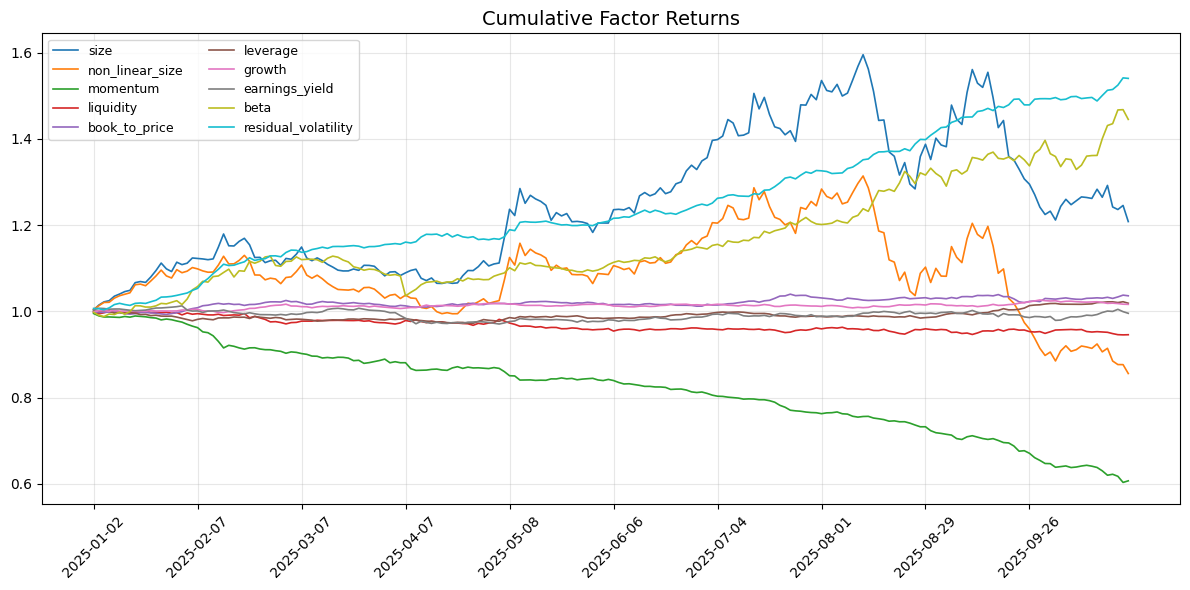

In [2]:
import matplotlib.pyplot as plt
import numpy as np

df_facret = pd.concat(facret_lst,axis=1).T
df_facret.index = [f[:10] for f in files]
df_facret_cum = (1 + df_facret).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_facret_cum.iloc[:, 32:]

df_plot.plot(ax=ax, linewidth=1.2)
# ✅ 图例
ax.legend(loc='best', fontsize=9, ncol=2)
# ✅ 横轴刻度稀疏（核心）
n = len(df_plot.index)
step = max(n // 10, 1)   # 最多显示10个刻度
ax.set_xticks(np.arange(0, n, step))
ax.set_xticklabels(df_plot.index[::step], rotation=45)

ax.grid(alpha=0.3)
ax.set_title("Cumulative Factor Returns", fontsize=14)
plt.tight_layout()
plt.show()

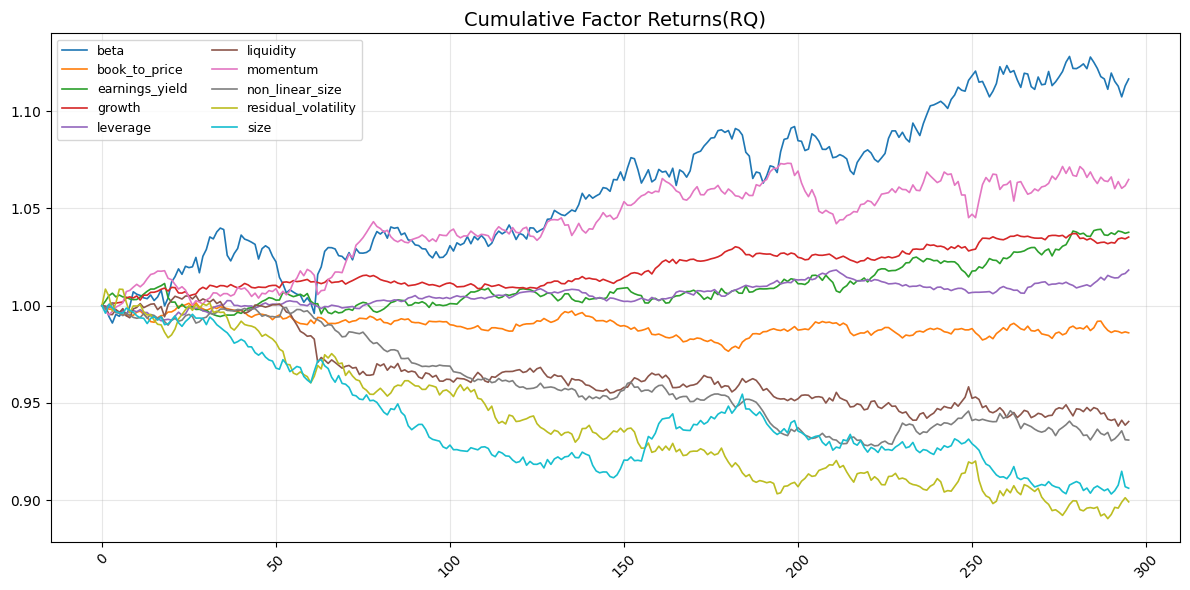

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

rq_facret = pd.concat([pd.DataFrame(0, index=[0], columns=rq_facret.columns), rq_facret], ignore_index=True)
rq_facret.drop("comovement",axis=1,inplace=True)
df_plot = (1 + rq_facret.iloc[:, :10]).cumprod()

df_plot.plot(ax=ax, linewidth=1.2)

ax.legend(loc='best', fontsize=9, ncol=2)
ax.set_title("Cumulative Factor Returns(RQ)", fontsize=14)
# ✅ 自动控制刻度（关键）
plt.xticks(rotation=45)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

分析因子收益率表现（结合历史）

In [ ]:
# df = df.sort_index()
dt = "2025-03-25"
dt = pd.to_datetime(dt)

if dt not in rq_facret.index:
    raise ValueError("日期不在数据中")

# --- 当天收益 ---
today_ret = rq_facret.loc[dt]

# --- 历史数据（不含当天） ---
hist = rq_facret.loc[:dt].iloc[:-1]
ret_5 = (1 + hist.tail(5)).prod() - 1
ret_22 = (1 + hist.tail(22)).prod() - 1
rank_pct = hist.apply(lambda x: (x <= today_ret[x.name]).sum() / len(x))

# --- 汇总 ---
result = pd.DataFrame({
    "today_ret": today_ret,
    "ret_5d": ret_5,
    "ret_22d": ret_22,
    "percentile": rank_pct
})
result = result.iloc[:10]

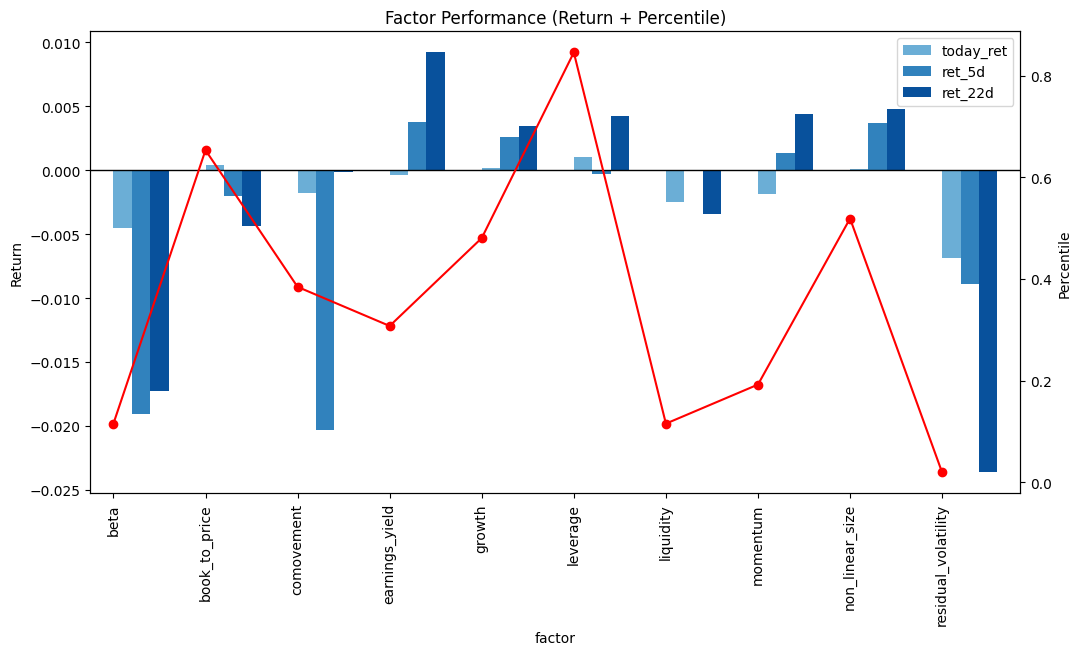

In [109]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))
colors = ["#6baed6", "#3182bd", "#08519c"]
# 左轴：收益
cols_ret = ["today_ret", "ret_5d", "ret_22d"]
result[cols_ret].plot(kind='bar', ax=ax1, position=0, width=0.6, color=colors)

ax1.set_ylabel("Return")
ax1.axhline(0, color='black', linewidth=1)

# 右轴：percentile
ax2 = ax1.twinx()
result["percentile"].plot(
    kind='line', ax=ax2, color='red', marker='o'
)

ax2.set_ylabel("Percentile")

plt.title("Factor Performance (Return + Percentile)")
plt.xticks(rotation=45)
plt.show()

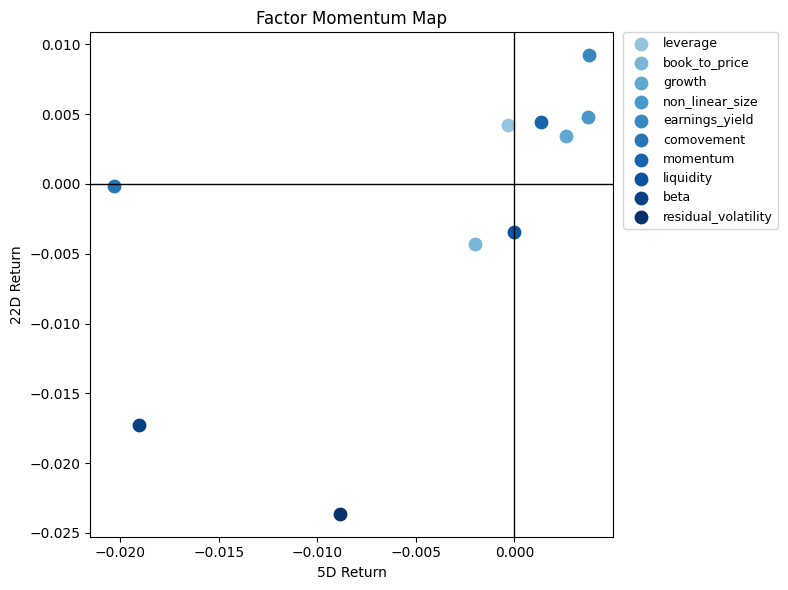

In [114]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

result = result.sort_values("today_ret",ascending=False)
fig, ax = plt.subplots(figsize=(8,6))
colors = cm.Blues(np.linspace(0.4, 1, len(result)))

# 画散点
for i, (idx, row) in enumerate(result.iterrows()):
    ax.scatter(row["ret_5d"],row["ret_22d"],color=colors[i],s=80,label=idx)

# 坐标轴
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("5D Return")
ax.set_ylabel("22D Return")
ax.set_title("Factor Momentum Map")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9
)

plt.tight_layout()
plt.show()

组合最优化

In [33]:
stk_ids = base_data.code.tolist()
dt = base_data.tradadate[0]
macd = get_factor(stk_ids,['MACD_HIST'],dt,dt).dropna(how="any")
df_reg = macd.reset_index().merge(base_data[["code","ret"]],left_on="order_book_id",right_on="code")
df_reg

,order_book_id,date,MACD_HIST,code,ret
0,002722.XSHE,2025-01-03,-0.567250,002722.XSHE,-0.042294
1,300946.XSHE,2025-01-03,-0.814616,300946.XSHE,-0.049981
2,000981.XSHE,2025-01-03,-0.131327,000981.XSHE,0.100000
3,001231.XSHE,2025-01-03,-0.607583,001231.XSHE,-0.028279
4,002009.XSHE,2025-01-03,-0.298004,002009.XSHE,-0.099871
...,...,...,...,...,...
5102,603326.XSHG,2025-01-03,-0.238404,603326.XSHG,-0.059308
5103,600526.XSHG,2025-01-03,-0.109297,600526.XSHG,-0.031818
5104,002104.XSHE,2025-01-03,-0.315424,002104.XSHE,-0.044615
5105,603097.XSHG,2025-01-03,-0.464298,603097.XSHG,-0.073246


原始数据量：5107 → 清洗后数据量：4220


d:\Ana\envs\rqsdk\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Ana\envs\rqsdk\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Ana\envs\rqsdk\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Ana\envs\rqsdk\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Ana\envs\rqsdk\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

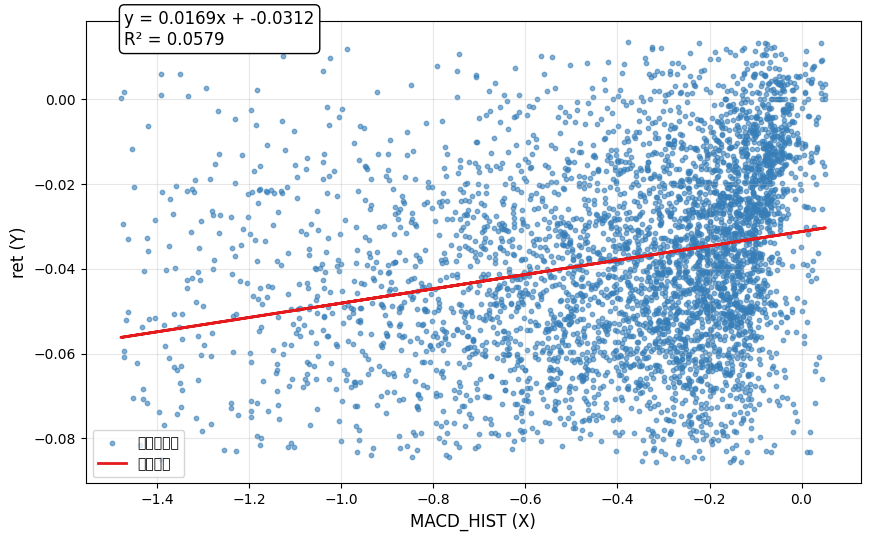

          MACD_HIST → ret 线性回归方程摘要
                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     259.0
Date:                  周五, 27 3月 2026   Prob (F-statistic):           1.32e-56
Time:                        13:09:02   Log-Likelihood:                 10235.
No. Observations:                4220   AIC:                        -2.047e+04
Df Residuals:                    4218   BIC:                        -2.045e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.

In [44]:
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

x = df_reg['MACD_HIST']
y = df_reg['ret']

q_x_low = x.quantile(0.05)
q_x_high = x.quantile(0.95)
q_y_low = y.quantile(0.05)
q_y_high = y.quantile(0.95)

# 过滤数据
df_clean = df_reg[
    (df_reg['MACD_HIST'] >= q_x_low) & (df_reg['MACD_HIST'] <= q_x_high) &
    (df_reg['ret'] >= q_y_low) & (df_reg['ret'] <= q_y_high)
]

x_clean = df_clean['MACD_HIST']
y_clean = df_clean['ret']

print(f"原始数据量：{len(df_reg)} → 清洗后数据量：{len(df_clean)}")

# 线性拟合（得到斜率、截距）
slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)

# 画图
plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.6, color='#377eb8', label='原始数据点')

plt.plot(x_clean, intercept + slope * x_clean, color='#e41a1c', linewidth=2, label='拟合直线')

equation = f'y = {slope:.4f}x + {intercept:.4f}\nR² = {r_value**2:.4f}'
plt.annotate(equation, xy=(0.05, 0.95), xycoords='axes fraction', 
             fontsize=12, bbox=dict(boxstyle='round', facecolor='white'))

plt.xlabel('MACD_HIST (X)', fontsize=12)
plt.ylabel('ret (Y)', fontsize=12)
#plt.title('MACD_HIST 与 ret 散点图 + 线性拟合', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

X_sm = sm.add_constant(x_clean)  # 增加截距项
model = sm.OLS(y_clean, X_sm).fit()
print("="*60)
print("          MACD_HIST → ret 线性回归方程摘要")
print("="*60)
print(model.summary())

测算一下特质收益矩阵【发现用米筐的合适】

In [3]:
import pandas as pd
spedir = "E:/SJTU/实习/国泰海通/barra因子/result/"
spe_ret = pd.read_excel(f"{spedir}/whole_mkt特质收益率截止至2026-03-25.xlsx",index_col=0)
df_speret = spe_ret.loc["2025-01-03"].dropna()
df_speret

000001.XSHE    0.007989
000002.XSHE    0.010067
000004.XSHE   -0.025121
000006.XSHE    0.003894
000007.XSHE   -0.004903
                 ...   
688799.XSHG    0.001300
688800.XSHG    0.057781
688819.XSHG    0.006302
688981.XSHG    0.016408
689009.XSHG    0.057115
Name: 2025-01-03, Length: 5122, dtype: float64

In [36]:
#结构化调整特质收益矩阵
import numpy as np
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/"
E0 = 1.05

for i in range(63,len(spe_ret)):
    dt = spe_ret.index[i]
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{dt}.pkl").iloc[:,:12]
    df_base = pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{dt}.pkl")
    df_barra = df_barra.merge(df_base,left_on="order_book_id",right_on="code")
    df_barra.set_index('order_book_id', inplace=True)
    row = spe_ret.loc[dt].dropna()
    stk = row.index.tolist()
    dt_ret = spe_ret.iloc[i-63:i][stk]
    
    Q1 = dt_ret.quantile(0.25)
    Q3 = dt_ret.quantile(0.75)
    sigma_robust = (Q3 - Q1) / 1.35
    sigma_sample = dt_ret.std()
    sigma_nw = sigma_sample #NW sigma（先用 sample 代替）

    Zu = np.abs(sigma_sample - sigma_robust) / (sigma_robust + 1e-8)
    h = dt_ret.notna().sum()
    gamma1 = np.clip((h - 0) / 42, 0, 1)
    gamma2 = np.clip(np.exp(1 - Zu), 0, 1)
    gamma = gamma1 * gamma2
    
    #结构化回归
    valid = (gamma == 1) & sigma_nw.notna()
    y = np.log(sigma_nw[valid] + 1e-8)
    valid_align = valid.reindex(df_barra.index).fillna(False)
    X_reg = df_barra.loc[valid_align].iloc[:,1:11].values #第一列变为索引了

    # ⭐⭐⭐ WLS权重（市值） ⭐⭐⭐
    cap = df_barra.loc[valid_align,'capital'].values
    w = np.sqrt(cap)   # 防止0
    X_w = X_reg * w[:, None]
    y_w = y.values * w
    
    # 回归求解
    b = np.linalg.lstsq(X_w, y_w, rcond=None)[0]

    # ---------- 结构化sigma ----------
    X_all = df_barra.iloc[:,1:11].values
    sigma_str = E0 * np.exp(X_all @ b)
    sigma_str = pd.Series(sigma_str, index=df_barra.index)

    # ---------- 最终sigma ----------
    sigma_hat = gamma * sigma_nw + (1 - gamma) * sigma_str

    # ---------- 协方差 ----------
    cov_e = np.diag((sigma_hat ** 2).values)
    break
cov_e

C:\Windows\Temp\ipykernel_40344\401107170.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  valid_align = valid.reindex(df_barra.index).fillna(False)


array([[6.90353246e-05, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 9.91074051e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 5.53513409e-04, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.65130654e-04, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.83686971e-04, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.04777838e-03]])

In [ ]:
tag = "300008.XSHE"
print(sigma_sample[tag],sigma_robust[tag],gamma[tag],sigma_str[tag])
np.exp(df_barra.iloc[:,1:11].loc[tag] @ b )

0.033627831363382904 0.013866331547075986 0.6536772349586225 139.13284376009054


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
variance = sigma_hat ** 2
#plt.scatter(temp.index,temp.values)
#sns.boxplot(temp)
variance

000001.XSHE    0.000069
000002.XSHE    0.009911
000004.XSHE    0.000554
000006.XSHE    0.000810
000007.XSHE    0.000247
                 ...   
688799.XSHG    0.000208
688800.XSHG    0.002409
688819.XSHG    0.000265
688981.XSHG    0.000484
689009.XSHG    0.001048
Length: 5144, dtype: float64

=== 两种波动率的数值差异统计 ===
           方法1_波动率      方法2_波动率         绝对差值      相对差值(%)
count  5141.000000  5141.000000  5141.000000  5141.000000
mean      1.918182     0.445771     2.299249   192.493957
std      56.494819     0.177112    56.459250    28.179717
min       0.000019     0.113535     0.009159     1.457659
25%       0.000206     0.314849     0.304191   199.270387
50%       0.000453     0.431413     0.414383   199.577529
75%       0.001096     0.557343     0.552076   199.743605
max    3153.056017     1.212099  3152.326588   199.950895

=== 差异最大的10只股票 ===
                 方法1_波动率   方法2_波动率         绝对差值     相对差值(%)
300615.XSHE  3153.056017  0.729430  3152.326588  199.907485
300008.XSHE  2323.900667  0.659028  2323.241639  199.886597
300534.XSHE   761.528344  0.522453   761.005891  199.725765
300251.XSHE   307.446208  0.902689   306.543519  198.829003
688078.XSHG   301.880178  0.550636   301.329542  199.271720
300995.XSHE   300.111022  0.875403   299.235619  198.836621
300634.XSHE   258

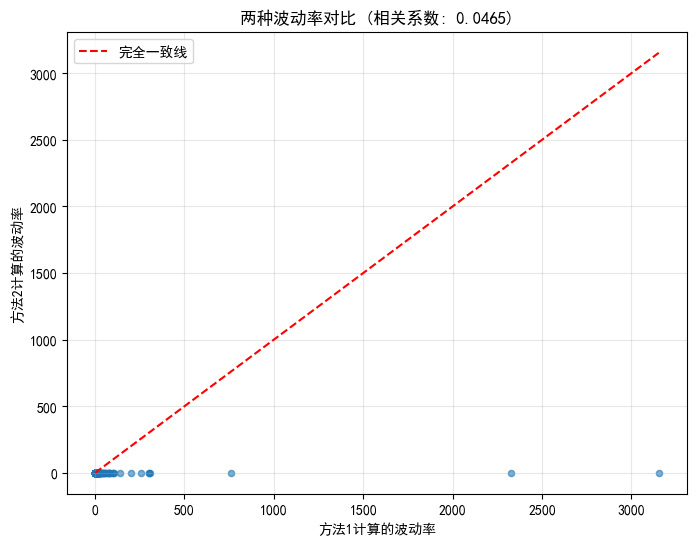

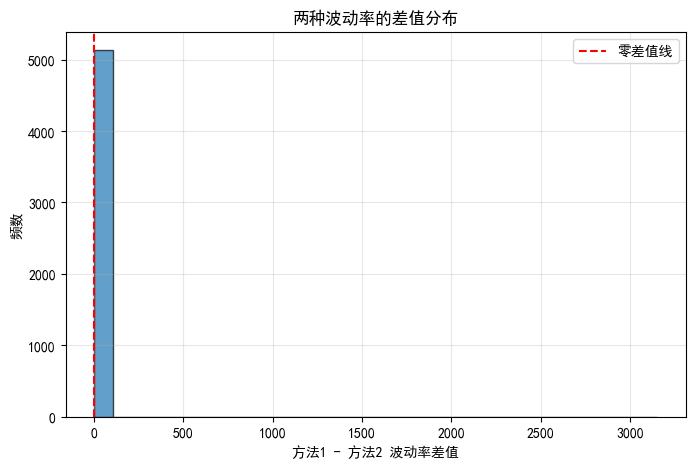

In [114]:
from scipy.stats import probplot

# 1. 强制转成 一维 Series，保证维度一样
vol1 = variance.squeeze()  # 去掉多余维度
vol1 = vol1[vol1 < vol1.quantile(1)]
vol2 = variance_rq.squeeze()

# 2. 对齐索引（必须做）
vol1, vol2 = vol1.align(vol2, join='inner')

# ---------------------- 2. 数值对比 ----------------------
vol_compare = pd.DataFrame({
    '方法1_波动率': vol1,
    '方法2_波动率': vol2,
    '绝对差值': np.abs(vol1 - vol2),
    '相对差值(%)': np.abs(vol1 - vol2) / ((vol1 + vol2)/2 + 1e-8) * 100  # 加1e-8防除0
})

print("=== 两种波动率的数值差异统计 ===")
print(vol_compare.describe())
print("\n=== 差异最大的10只股票 ===")
print(vol_compare.sort_values('绝对差值', ascending=False).head(10))

corr_pearson = vol1.corr(vol2)
corr_spearman = vol1.corr(vol2, method='spearman')
print(f"\n=== 相关性检验 ===")
print(f"皮尔逊相关系数: {corr_pearson:.4f}")
print(f"斯皮尔曼秩相关系数: {corr_spearman:.4f}")

# ---------------------- 3. 可视化对比 ----------------------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 图1：散点图
plt.figure(figsize=(8, 6))
plt.scatter(vol1, vol2, alpha=0.6, s=20)
min_val = min(vol1.min(), vol2.min())
max_val = max(vol1.max(), vol2.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='完全一致线')
plt.xlabel('方法1计算的波动率')
plt.ylabel('方法2计算的波动率')
plt.title(f'两种波动率对比 (相关系数: {corr_pearson:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 图2：差值分布直方图
diff = vol1 - vol2
plt.figure(figsize=(8, 5))
plt.hist(diff, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(0, color='r', linestyle='--', label='零差值线')
plt.xlabel('方法1 - 方法2 波动率差值')
plt.ylabel('频数')
plt.title('两种波动率的差值分布')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [108]:
variance_f = np.diag(R_cov)
pd.Series(variance_f)

0        3.603491
1       16.966333
2        2.811504
3        6.817039
4        9.594015
          ...    
5138    10.833773
5139     2.905484
5140     8.439617
5141    14.332744
5142     6.296529
Length: 5143, dtype: float64

In [7]:
import pandas as pd
import numpy as np
import os
from functools import reduce
from scipy import stats
import cvxpy as cp
from datetime import datetime
from collections import defaultdict

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/"
spedir = "E:/SJTU/实习/国泰海通/barra因子/result/"

def weighted_orthogonize(X, w):
    """
    X: 原始的因子暴露矩阵，因子重要性逐级递减
    w: WLS回归权重，向量
    """
    N, K = X.shape
    X_orth = X.copy().astype(float)

    for j in range(K):
        xj = X_orth[:, j]

        for i in range(j):
            xi = X_orth[:, i]

            numerator = np.sum(w * xj * xi)
            denominator = np.sum(w * xi * xi)

            if denominator < 1e-12:
                continue

            proj_coeff = numerator / denominator
            X_orth[:, j] = X_orth[:, j] - proj_coeff * xi

    return X_orth

def orthogonized_factor_cov(X, w):
    return X.T @ (w[:, None] * X)

def orthogonalize_pair(df, col1, col2):
    x1 = df[col1].values
    x2 = df[col2].values
    
    beta = np.dot(x1, x2) / np.dot(x1, x1)
    x2_new = x2 - beta * x1
    
    df[col2] = x2_new
    return df
files = sorted(os.listdir(f"{srcdir}/base_data/000905"))
#spe_ret = pd.read_excel(f"{spedir}/000905特质收益率截止至2025-10-31.xlsx",index_col=0)
alpha_name = 'MACD_HIST'
#lam = 1
slope, intercept = 0.0169, -0.0312
num_ori = 100
pair_lst = [['earnings_yield', 'liquidity'],['beta', 'residual_volatility'],['non_linear_size', 'size']]
rou_list = [-0.308,0.357,0.510] #根据pair_lst去查数
ret_dict = defaultdict(list)#{}
dual_dict = defaultdict(list) #测试lam取值的时候改！
error_dt = defaultdict(list)
lam_lst = []


for i in range(len(files)-1): #1 len(files)+5
    # if w0 is None:

    #明确时间域
    alpha_dt = files[i]#"2025-04-10.pkl"#
    #barra_dt = files[i+1][:10]
    base_dt = files[i+1]#dt + ".pkl"#
    print(f"获取{alpha_dt[:10]}天的因子数据并收盘买入，{base_dt[:10]}天卖出")

    #读取数据，最优化
    df_base = pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{base_dt}")
    df_alpha = pd.read_pickle(f"{srcdir}/alpha/macd/{alpha_dt}")
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{alpha_dt}") #000905标准化2
    X_center = pd.read_pickle(f"{srcdir}/barra_data/000905标准化3_含行业/{alpha_dt}") #
    variance_frq = pd.read_pickle(f"{srcdir}/fac_ret_cov/{alpha_dt}")
    variance_rq = pd.read_pickle(f"{srcdir}/spe_ret_cov/{alpha_dt}")

    df_base['order_book_id'] = df_base['code'].str.replace('.SZ','.XSHE').str.replace('.SH','.XSHG')

    dfs = [df_alpha,df_barra,df_base]
    df_reg = reduce(lambda left, right:left.merge(right,on="order_book_id"),dfs)    #t天的alpha、因子暴露和t+1天的收益
    Rhat_series = (intercept + slope * df_reg[alpha_name])
    Rhat = Rhat_series.fillna(Rhat_series.median()).values
    Num = len(df_reg)
    # if Num < 500:
    #     change_dt.append(base_dt[:10])
    # 【QUSETION! 6-16中证500成分股变更！】
    orth_order = [x for x in variance_frq.index.tolist()[:11] if x != "comovement"]#["beta","momentum","size","non_linear_size","residual_volatility","liquidity","book_to_price","earnings_yield","growth","leverage"]
    ind_order = list(variance_frq.columns[11:].values)
    X_original = df_reg[orth_order+ind_order].values #风格+行业
    stk_order = df_reg["order_book_id"].tolist()
    #部分正交化
    flat_pair = [item for sublist in pair_lst for item in sublist]
    non_orth = [var for var in orth_order if var not in flat_pair]
    num_non = len(non_orth) #non_orth + ind_order / non_orth
    X_center =X_center.set_index("order_book_id").loc[stk_order, non_orth + flat_pair] #ind_order + 
    for c1, c2 in pair_lst:
        X_center = orthogonalize_pair(X_center, c1, c2)
    X_center = X_center.values
    #X_center = X_center.set_index("order_book_id").loc[stk_order,orth_order].values #风格

    w_m = np.sqrt(df_reg.capital.values)
    w_m = w_m / w_m.sum()
    #X_orth = weighted_orthogonize(X_ori,w_m)

    #F_cov = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values#orthogonized_factor_cov(X_orth,w_m)
    #D_diag = variance_rq.reindex(df_reg["code"]).values.ravel()
    #sqrtD = np.sqrt(D_diag)
    #根据barra做进一步完善
    F_cov_raw = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values
    diag = np.diag(np.diag(F_cov_raw))
    F_cov = 0.9 * F_cov_raw + 0.1 * diag
    D_diag = variance_rq.reindex(df_reg["code"]).values.ravel()
    lower = np.percentile(D_diag, 1)
    upper = np.percentile(D_diag, 99)
    D_diag = np.clip(D_diag, lower, upper)
    sqrtD = np.sqrt(D_diag)
    w0 = np.ones(len(D_diag)) / len(D_diag)
    risk = w0 @ X_original @ F_cov @ X_original.T @ w0 + w0 @ np.diag(D_diag) @ w0
    ret  = np.mean(np.abs(Rhat))
    lam0 = ret / risk
    lam_lst.append(lam0)
    print(f"{base_dt}选择的lam：{lam0}")
    
    #R_cov = X_orth @ F_cov @ X_orth.T
    #设置权重向量的初始值【根据因子信号/等权】
    w_ori = np.zeros_like(Rhat)
    idx = np.argsort(Rhat)[::-1][:num_ori]
    w_ori[idx] = np.exp(-np.arange(num_ori)/20)
    w_ori /= w_ori.sum()

    print(f"开始最优化{base_dt[:10]}组合 | {datetime.now()}")
    #turnover = 0.005
    w = cp.Variable(Num)
    w.value = w_ori
    Xo = X_original.T @ w
    Xp = X_center.T @ w
    lam = cp.Parameter(nonneg=True,value=1) #lam0
    #penalty = cp.sum_squares(cp.pos(Xp - x_max)) + cp.sum_squares(cp.pos(x_min - Xp))
    #gamma = cp.Parameter(nonneg=True)
    
    objective = cp.Minimize(
            lam * (cp.quad_form(Xo, F_cov) + cp.sum_squares(cp.multiply(sqrtD, w))) - cp.sum(cp.multiply(Rhat, w)) #+ gamma*penalty
        )

    for l_val in [0.01]:#[0.01,0.1,0.3,0.5,1]:
        #gamma.value = l_val
        x_min = [-l_val] * num_non
        x_max = [l_val] * num_non
        for i, (c1, c2) in enumerate(pair_lst):
            current_rou2 = (rou_list[i])**2  # 取出当前配对的 rou
            x_min.append(-l_val),x_min.append(-l_val * np.sqrt((1 - current_rou2)))
            x_max.append( l_val),x_max.append(-l_val * np.sqrt((1 - current_rou2)))
        #x_min = np.full(X_center.shape[1], -l_val) #偏离 个标准差
        #x_max = np.full(X_center.shape[1], l_val)
        constraints = [
            cp.sum(w) == 1,
            w >= 0,
            #w <= 0.01,
            # #cp.abs(w - w0) <= turnover,
            Xp >= x_min,
            Xp <= x_max
        ]
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=True) #solver=cp.OSQP, #verbose=True #max_iter=10000,
   
            if w.value is None or np.any(np.isnan(w.value)):
                print(f"{base_dt[:10]}权重为空{prob.status}，等权买入")
                error_dt[l_val].append(f"{prob.status}_{base_dt[:10]}")
                w_opt = np.full(Num, 1/Num)
            else:
                dual_dict[l_val].append([constraints[i].dual_value for i in range(len(constraints))])
                w_opt = w.value

        except:
            print(f"{base_dt[:10]}最优化失败，等权买入")
            error_dt[l_val].append(base_dt[:10])
            w_opt = np.full(Num, 1/Num)
    

        R_true = df_reg.ret.values
        Rp_realized = w_opt @ R_true
        #ret_dict[base_dt]=Rp_realized
        ret_dict[l_val].append(Rp_realized)

    #print(f"完成最优化，实际收益为{Rp_realized} | {datetime.now()}")

    #更新收益率对齐系数
    x = df_reg[alpha_name]
    y = df_reg['ret']
    q_x_low, q_x_high, q_y_low, q_y_high = x.quantile(0.05), x.quantile(0.95), x.quantile(0.05), x.quantile(0.95)

    # 过滤数据
    df_clean = df_reg[
        (df_reg[alpha_name] >= q_x_low) & (df_reg[alpha_name] <= q_x_high) &
        (df_reg['ret'] >= q_y_low) & (df_reg['ret'] <= q_y_high)
    ]

    x_clean = df_clean[alpha_name]
    y_clean = df_clean['ret']

    #print(f"原始数据量：{len(df_reg)} → 清洗后数据量：{len(df_clean)}")

    # 线性拟合（得到斜率、截距）
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    

获取2025-01-02天的因子数据并收盘买入，2025-01-03天卖出
2025-01-03.pkl选择的lam：1.789227774609168
开始最优化2025-01-03组合 | 2026-04-14 16:51:28.716245
                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Apr 14 04:51:28 PM: Your problem has 5122 variables, 5143 constraints, and 1 parameters.
(CVXPY) Apr 14 04:51:28 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 14 04:51:28 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 14 04:51:28 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 14 04:51:28 PM: Compiling problem (target solver=OSQP).
(CVXPY)

In [26]:
#查看原始取值
factor_v = np.diag(X_original @ F_cov @ X_original.T)
scale = np.mean(factor_v) / np.mean(D_diag)
D_scaled = D_diag * scale
sqrtD_scaled = np.sqrt(D_scaled)
print("barra因子协方差统计：",pd.Series(factor_v.ravel()).describe())
print("特质收益协方差统计：",pd.Series(D_scaled.ravel()).describe())
print("收益预测统计：",pd.Series(Rhat.ravel()).describe())

barra因子协方差统计： count    5122.000000
mean        0.058855
std         0.034672
min         0.006014
25%         0.032221
50%         0.051988
75%         0.078711
max         0.257826
dtype: float64
特质收益协方差统计： count    5122.000000
mean        0.058855
std         0.024558
min         0.015507
25%         0.040272
50%         0.055190
75%         0.073864
max         0.169838
dtype: float64
收益预测统计： count    5122.000000
mean       -0.036846
std         0.011024
min        -0.245510
25%        -0.038747
50%        -0.034826
75%        -0.032762
max         0.109876
dtype: float64


In [2]:
# 修复后 —— 先算 .value，再运算！
term1 = (lam * cp.quad_form(Xo, F_cov)).value   # 正确！
term2 = (lam * cp.sum_squares(cp.multiply(sqrtD, w))).value  # 正确！
term3 = (-cp.sum(cp.multiply(Rhat, w))).value  # 正确！
total_obj = objective.value

print(f"因子方差项  = {term1:.6f}")
print(f"特异方差项  = {term2:.6f}")
print(f"收益项  = {term3:.6f}")
print(f"总目标值 = {total_obj:.6f}")

因子方差项  = 0.046066
特异方差项  = 0.015182
收益项  = -0.052586
总目标值 = 0.010725


In [ ]:
#关于最优化函数各部分量纲说明（D最大）
import matplotlib.pyplot as plt
#plt.plot(D_diag)
F_cov.ravel().max(),F_cov.ravel().mean() #(0.05441238261185568, 0.0002673383758434856)
D_diag.max(),D_diag.mean() #(0.9966425412350473, 0.3460361925159045)
#plt.plot((X_original @ F_cov @ X_original.T).ravel())
Rhat.max(),Rhat.mean() #(0.2008089999827868, -0.009992674817558628)
(X_original @ F_cov @ X_original.T).ravel().max(),(X_original @ F_cov @ X_original.T).ravel().mean() #(0.1218607, 0.007115682907068303)

(0.12186076823172319, 0.007115682907068303)

In [4]:
#print(len(error_dt))
print([len(error_dt[l_val]) for l_val in [0.01,0.1,0.3,0.5,1]])
error_dt

[0, 0, 0, 0, 199]


defaultdict(list,
            {1: ['2025-01-03',
              '2025-01-06',
              '2025-01-07',
              '2025-01-08',
              '2025-01-09',
              '2025-01-10',
              '2025-01-13',
              '2025-01-14',
              '2025-01-15',
              '2025-01-16',
              '2025-01-17',
              '2025-01-20',
              '2025-01-21',
              '2025-01-22',
              '2025-01-23',
              '2025-01-24',
              '2025-01-27',
              '2025-02-05',
              '2025-02-06',
              '2025-02-07',
              '2025-02-10',
              '2025-02-11',
              '2025-02-12',
              '2025-02-13',
              '2025-02-14',
              '2025-02-17',
              '2025-02-18',
              '2025-02-19',
              '2025-02-20',
              '2025-02-21',
              '2025-02-24',
              '2025-02-25',
              '2025-02-26',
              '2025-02-27',
              '2025-02-28',

In [36]:
print(orth_order)
X_center.T @ w_opt

['beta', 'book_to_price', 'earnings_yield', 'growth', 'leverage', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility', 'size']


array([-0.56381531,  0.16219816, -0.32690782,  0.42286889, -0.05026046,
       -0.14175657,  0.20045036,  0.26052979, -0.61175756,  0.54538134])

In [6]:
#进一步剖析策略优化情况
#prob.solver_stats
num_lst = []
# for dt,val in dual_dict.items(): #dt , LAM=1
#     if dt == 0:
#         continue
#     val[0][2], val[0][3] = val[0][2].astype(int), val[0][3].astype(int)
#     num_lst.append(len(np.where(val[0][1]==0)[0]))
#     if val[0][2].max() > 0:
#         idx = np.where(val[0][2]>0)[0]
#         print(f"{dt}天的{orth_order[idx]}风格因子【下限】紧约束")
#     if val[0][3].max() > 0:
#         idx = np.where(val[0][3]>0)[0]
#         print(f"{dt}天的{orth_order[idx]}风格因子【上限】紧约束")
res_dict = []
for l_val, day_list in dual_dict.items():
    # 直接遍历每一天（每个元素就是【当天的4个约束值】）
    for dt, daily_vals in zip(files[1:], day_list):
        # 解包当天4个值（按你原来的顺序：0,1,2,3）
        val0, val1, val2, val3 = daily_vals

        num_lst.append(len(np.where(val1 == 0)[0]))

        val2 = val2.astype(float)
        if val2.max() != 0:
            idx = np.where(val2 > 0)[0]
            factors = [(ind_order + orth_order)[i] for i in idx] #加行业
            res_dict.append([l_val, dt[:10], "lower_bond"]+[factors])
            print(f"{dt}天的{factors}风格因子【下限】紧约束")
        val3 = val3.astype(float)
        if val3.max() != 0:
            idx = np.where(val3 > 0)[0]
            factors_u = [(ind_order + orth_order)[i] for i in idx]
            res_dict.append([l_val, dt[:10], "upper_bond"]+[factors_u])
            print(f"{dt}天的{factors_u}风格因子【上限】紧约束")
print(f"策略平均每日配股{np.mean(num_lst),np.median(num_lst)}")
res_dict

2025-01-03.pkl天的['传媒', '农林牧渔', '商贸零售', '国防军工', '基础化工', '建筑材料', '建筑装饰', '房地产', '有色金属', '机械设备', '煤炭', '环保', '电力设备', '纺织服饰', '轻工制造', '非银金融', 'beta', 'earnings_yield', 'growth', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility', 'size']风格因子【下限】紧约束
2025-01-03.pkl天的['交通运输', '公用事业', '医药生物', '基础化工', '有色金属', '汽车', '煤炭', '电子', '石油石化', '计算机', '通信', '钢铁', '银行', '非银金融', '食品饮料', 'book_to_price', 'leverage', 'non_linear_size', 'size']风格因子【上限】紧约束
2025-01-06.pkl天的['传媒', '农林牧渔', '商贸零售', '国防军工', '基础化工', '建筑材料', '建筑装饰', '房地产', '有色金属', '机械设备', '环保', '电力设备', '纺织服饰', '轻工制造', '通信', '银行', '非银金融', 'beta', 'earnings_yield', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility']风格因子【下限】紧约束
2025-01-06.pkl天的['交通运输', '公用事业', '医药生物', '基础化工', '有色金属', '机械设备', '汽车', '煤炭', '电子', '石油石化', '美容护理', '计算机', '通信', '钢铁', '银行', '非银金融', '食品饮料', 'book_to_price', 'leverage', 'liquidity', 'non_linear_size', 'size']风格因子【上限】紧约束
2025-01-07.pkl天的['传媒', '农林牧渔', '商贸零售', '国防军工', '基础化工', '建筑材料', '建筑装饰', '房地产', '机械

[[0.1,
  '2025-01-03',
  'lower_bond',
  ['传媒',
   '农林牧渔',
   '商贸零售',
   '国防军工',
   '基础化工',
   '建筑材料',
   '建筑装饰',
   '房地产',
   '有色金属',
   '机械设备',
   '煤炭',
   '环保',
   '电力设备',
   '纺织服饰',
   '轻工制造',
   '非银金融',
   'beta',
   'earnings_yield',
   'growth',
   'liquidity',
   'momentum',
   'non_linear_size',
   'residual_volatility',
   'size']],
 [0.1,
  '2025-01-03',
  'upper_bond',
  ['交通运输',
   '公用事业',
   '医药生物',
   '基础化工',
   '有色金属',
   '汽车',
   '煤炭',
   '电子',
   '石油石化',
   '计算机',
   '通信',
   '钢铁',
   '银行',
   '非银金融',
   '食品饮料',
   'book_to_price',
   'leverage',
   'non_linear_size',
   'size']],
 [0.1,
  '2025-01-06',
  'lower_bond',
  ['传媒',
   '农林牧渔',
   '商贸零售',
   '国防军工',
   '基础化工',
   '建筑材料',
   '建筑装饰',
   '房地产',
   '有色金属',
   '机械设备',
   '环保',
   '电力设备',
   '纺织服饰',
   '轻工制造',
   '通信',
   '银行',
   '非银金融',
   'beta',
   'earnings_yield',
   'liquidity',
   'momentum',
   'non_linear_size',
   'residual_volatility']],
 [0.1,
  '2025-01-06',
  'upper_bond',
  ['交通运输',
   '公用事业',
   

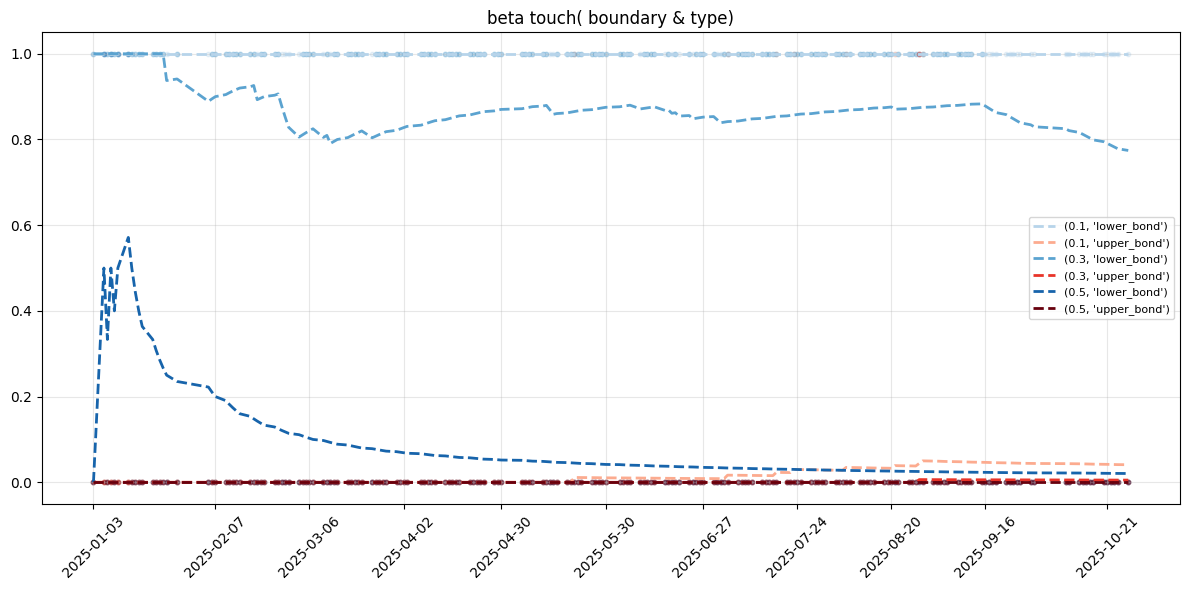

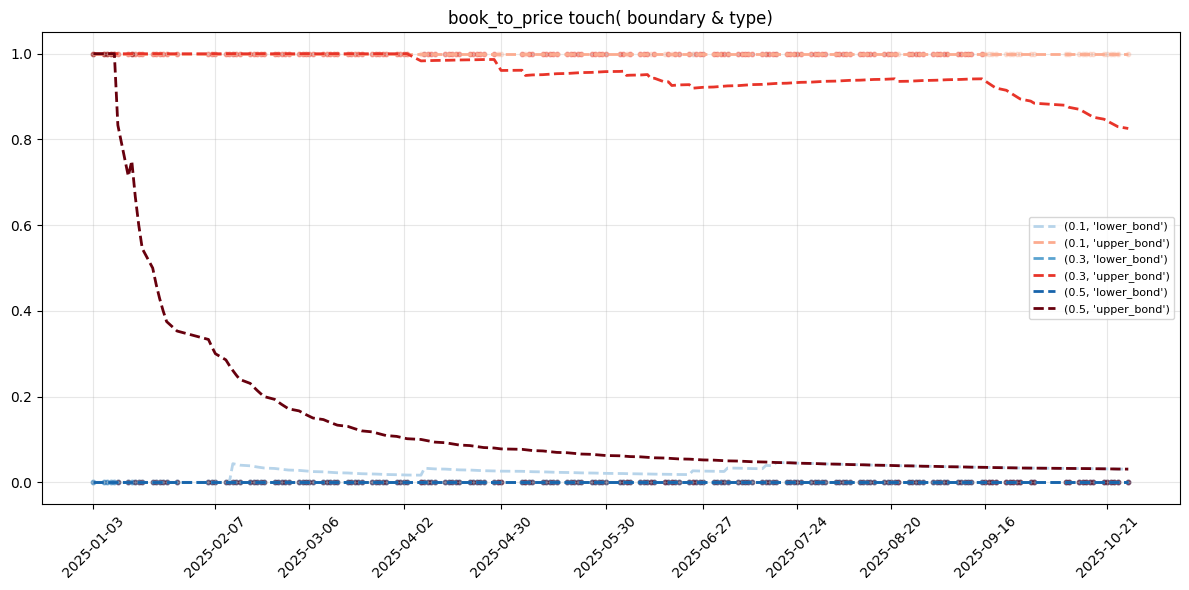

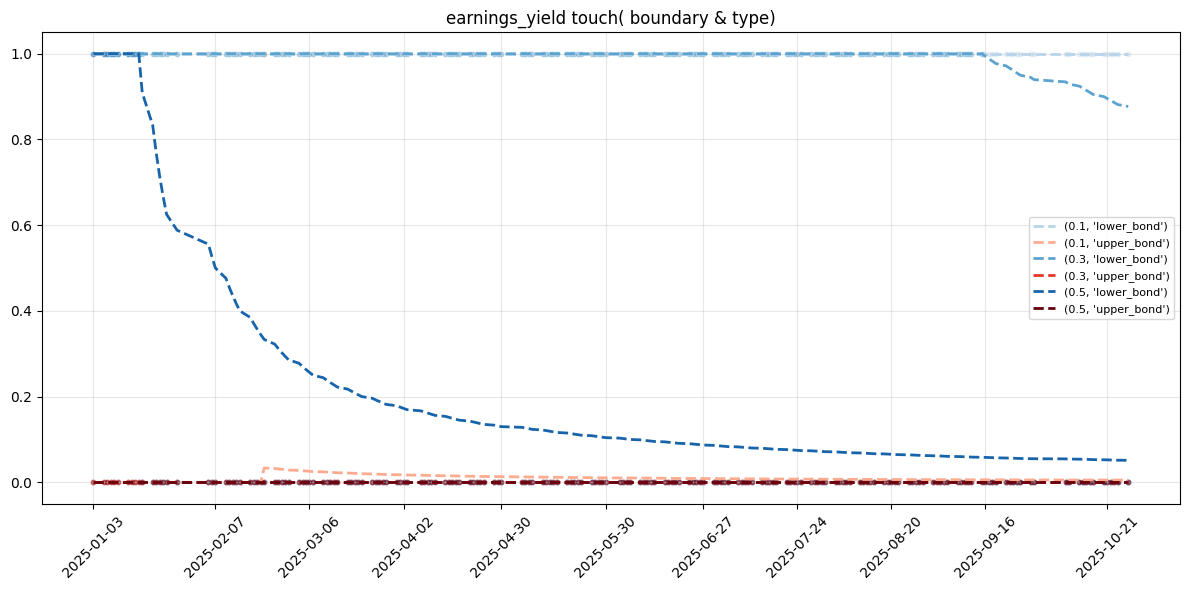

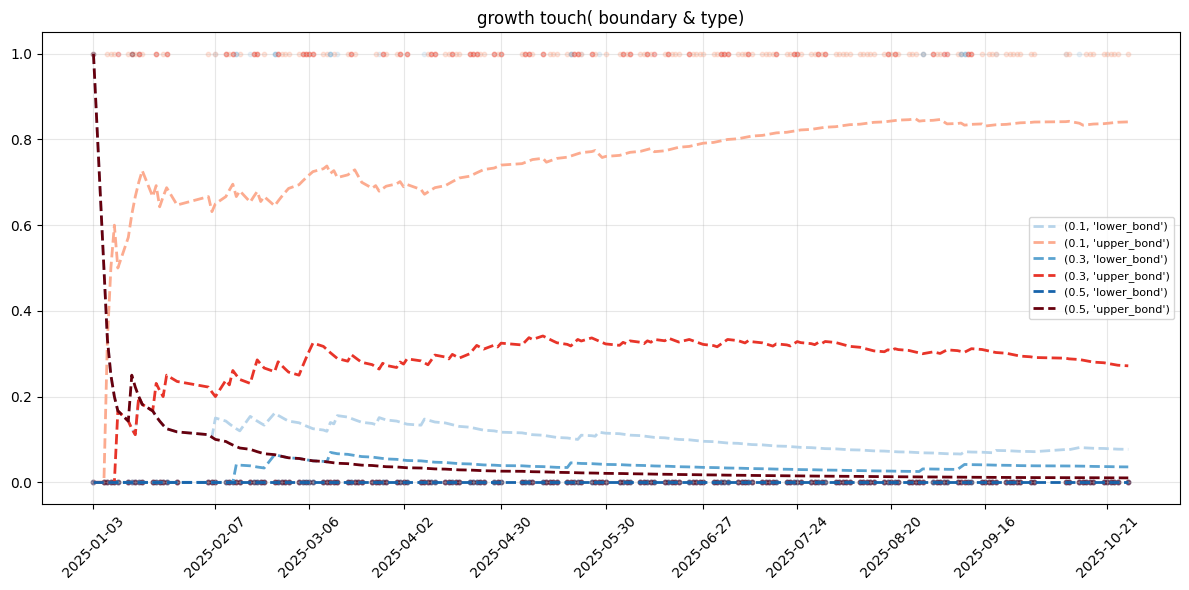

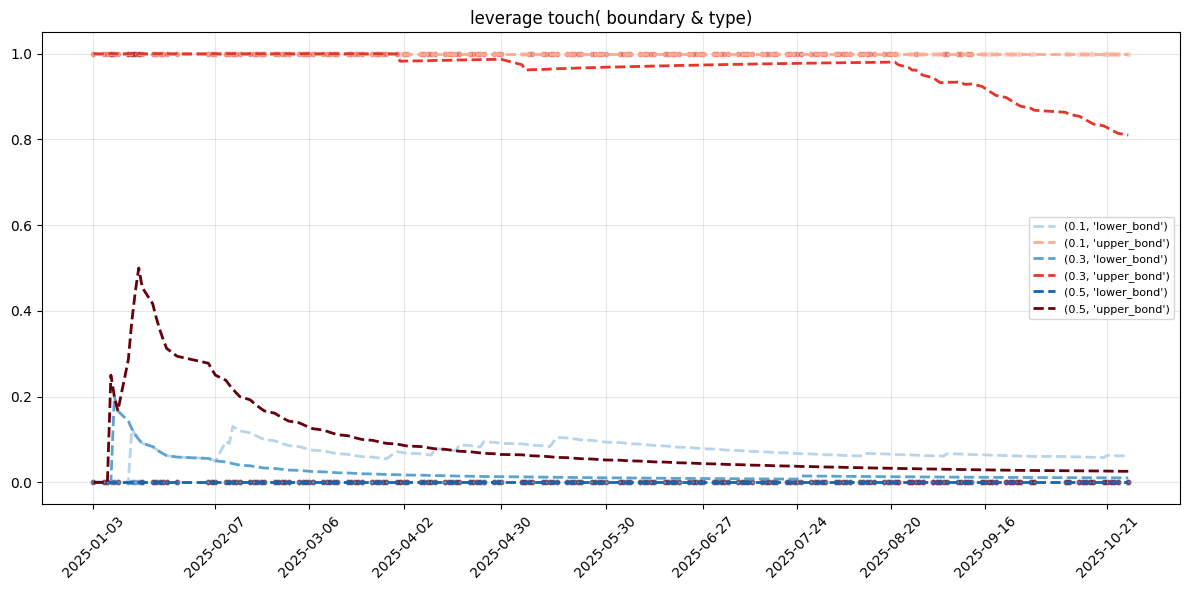

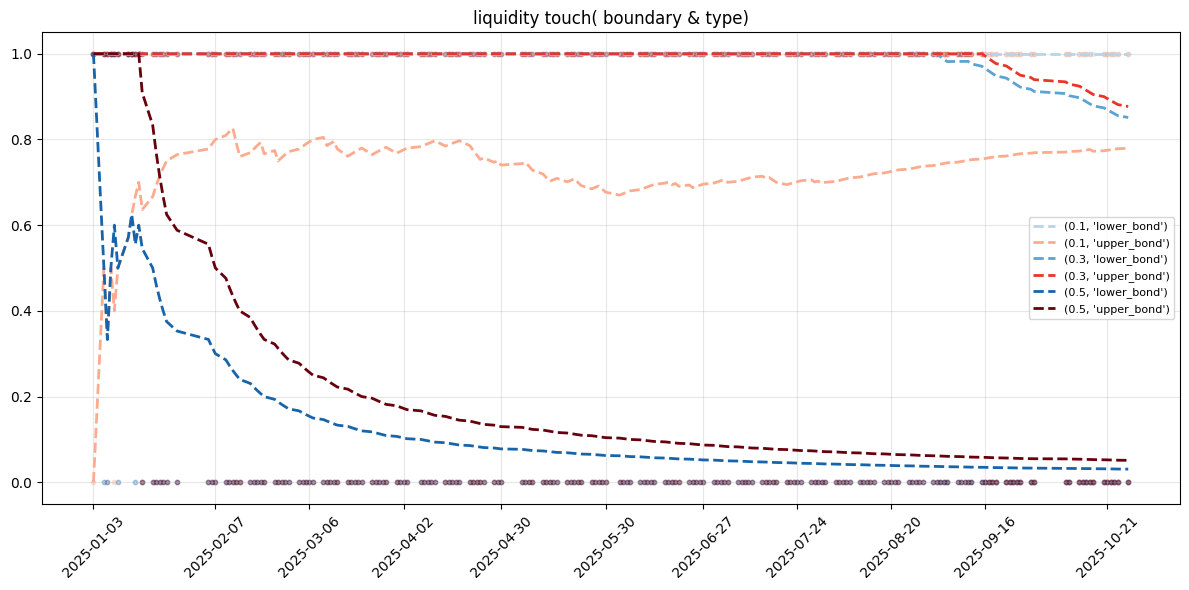

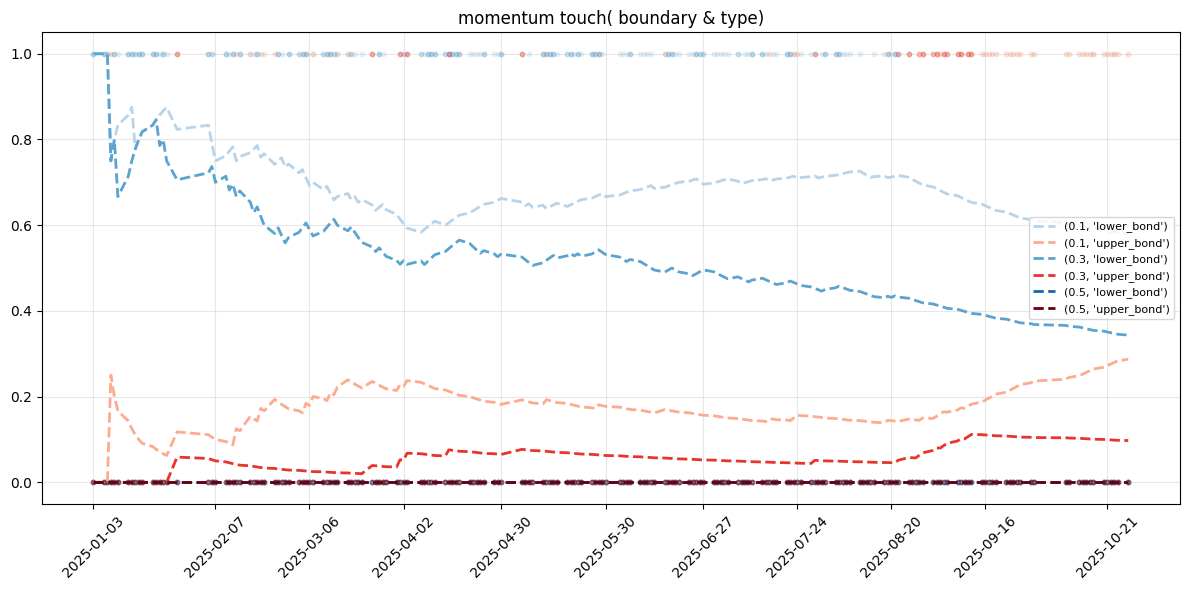

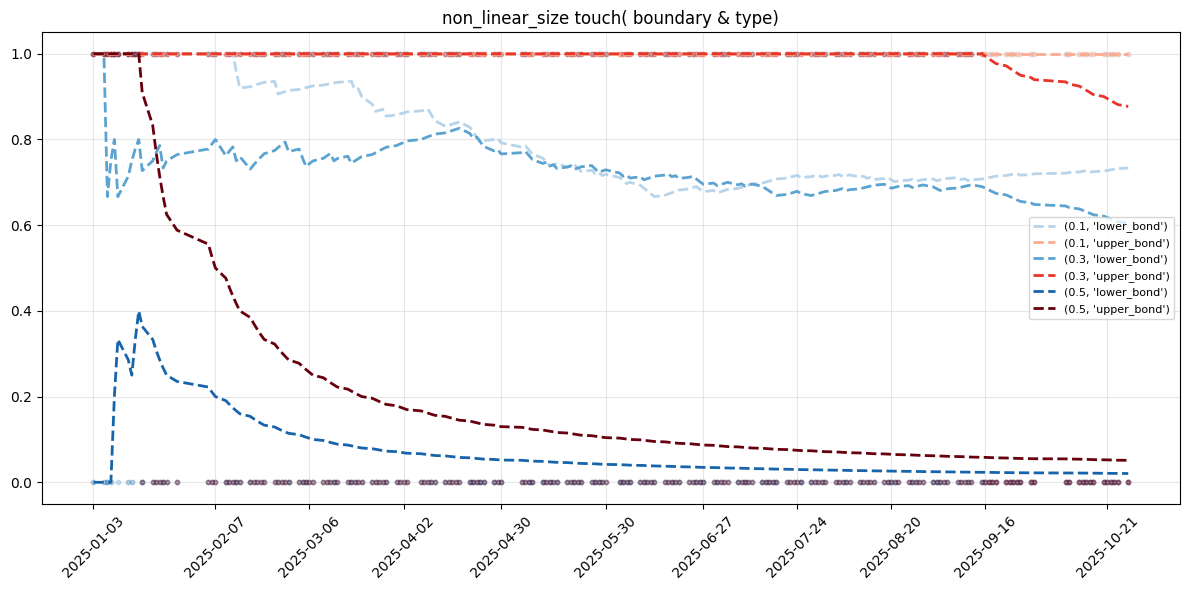

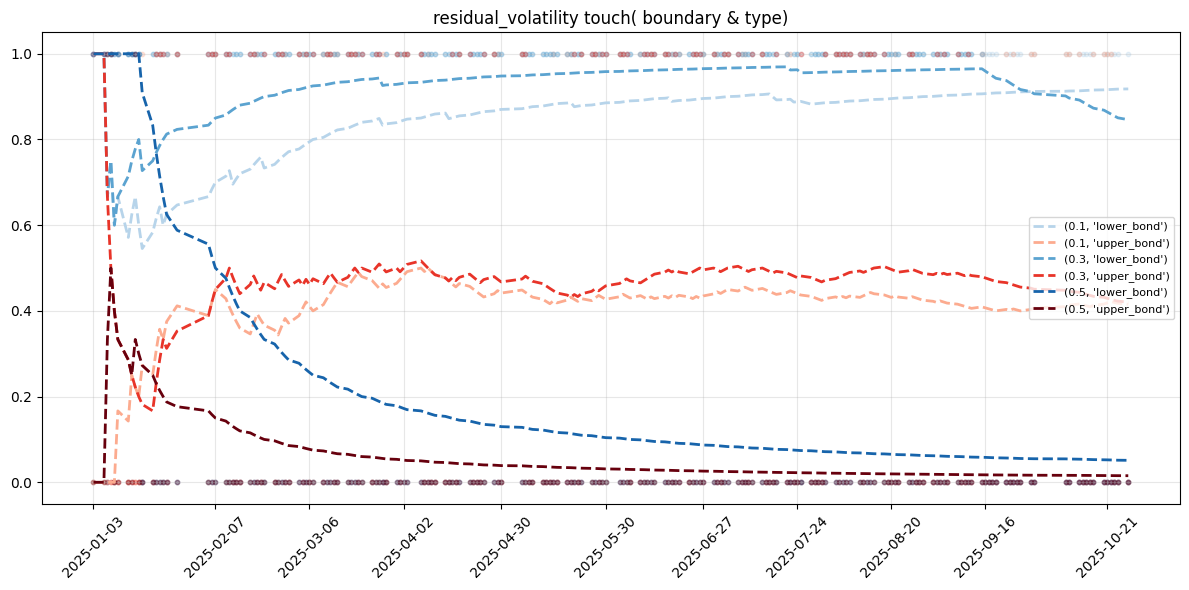

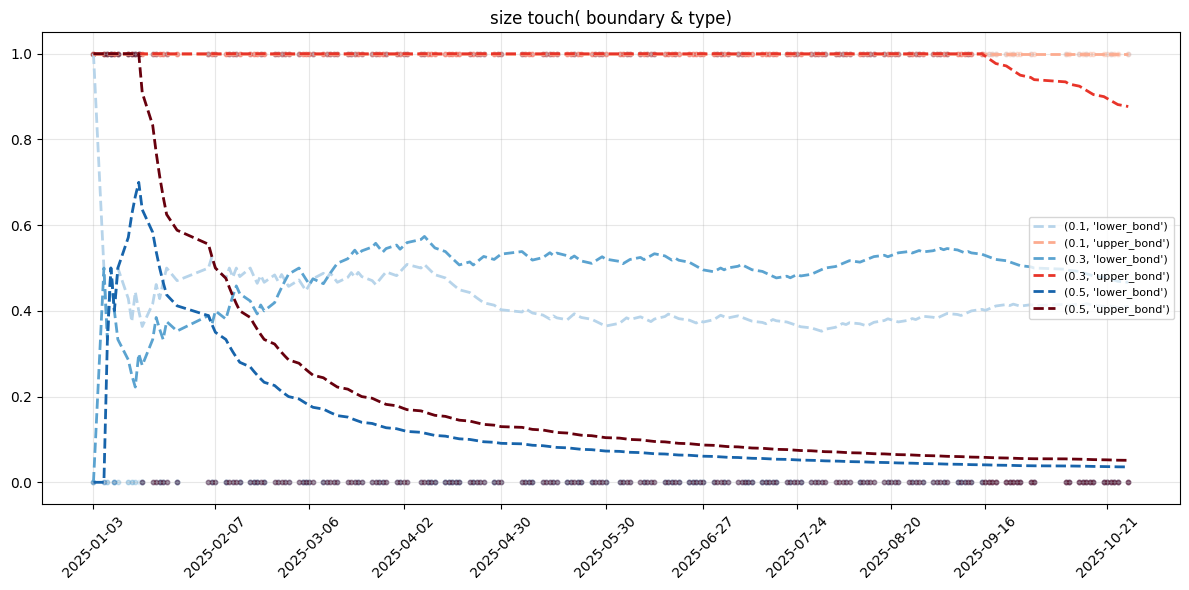

In [7]:
import matplotlib.pyplot as plt
import numpy as np
def parse_tag(tag):
    # tag = "(0.1, 'lower_bond')" 这种
    b, t = eval(tag)
    return float(b), t
def get_color(boundary, typ):
    # 归一化到 0~1
    norm = (boundary - b_min) / (b_max - b_min + 1e-8)
    if typ == 'lower_bond':
        return plt.cm.Blues(0.3 + 0.5 * norm)   # 浅蓝 → 稍深蓝
    else:
        return plt.cm.Reds(0.3 + 0.7 * norm)    # 浅红 → 深红
df = pd.DataFrame(res_dict,columns=["boundary","tradadate","type","factors"])
res = []

for _, row in df.iterrows():
    factors = row['factors']
    onehot = [1 if f in factors else 0 for f in orth_order]
    res.append(list(row) + onehot)

new_cols = list(df.columns) + orth_order
df_new = pd.DataFrame(res, columns=new_cols)
df_new["count"] = df_new[orth_order].sum(axis=1)
for fac in orth_order:
    temp = df_new[["boundary","tradadate","type"]+[fac]]
    res = []
    for g,df_s in temp.groupby(["boundary","type"]):
        tag = str(g)
        df_s.set_index("tradadate",inplace=True)
        df_s = df_s.rename({fac:tag},axis=1)
        res.append(df_s[[tag]])
    df_g = pd.concat(res,axis=1).fillna(0)
    #df_g.to_excel(f"{spedir}/组合优化/{fac}各约束强度的触线情况.xlsx")
    df_g.index= pd.to_datetime(df_g.index)
    # 提取 boundary 分布（用于归一化）
    boundaries = [parse_tag(c)[0] for c in df_g.columns]
    b_min, b_max = min(boundaries), max(boundaries)
    plt.figure(figsize=(12,6))
    # 1️⃣ 散点
    for col in df_g.columns:
        b, t = parse_tag(col)
        color = get_color(b, t)
        
        plt.scatter(df_g.index, df_g[col],
                    s=10, alpha=0.3, color=color)
    # 2️⃣ 趋势线（虚线）
    df_mean = df_g.expanding().mean()
    for col in df_mean.columns:
        b, t = parse_tag(col)
        color = get_color(b, t)
        
        plt.plot(df_mean.index, df_mean[col],
                linestyle='--', linewidth=2,
                color=color, label=col)
    # 美化
    step = max(1, len(df_g)//10)
    plt.xticks(df_g.index[::step], df_g.index[::step].strftime('%Y-%m-%d'), rotation=45)
    plt.title(f"{fac} touch( boundary & type)")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8,loc='center right')
    plt.tight_layout()
    plt.savefig(f"{spedir}/组合优化/{fac}各约束触线图.png")
    #plt.show()
#df["count"] = df.iloc[:,3:].notna().sum(axis=1)
# df.columns = ["boundary","tradadate","type"] + df.columns[3:].tolist()

# for t in ["upper_bond","lower_bond"]:
#     temp = df[df["type"]==t]
#     temp.to_excel(f"{spedir}/组合优化/各约束强度的触线详情{t}.xlsx")
#     df_lst = []
#     for g,df_sm in temp.groupby("boundary"):
#         tag = str(g)
#         df_sm.set_index("tradadate",inplace=True)
#         df_sm = df_sm.rename({"count":tag},axis=1)
#         df_lst.append(df_sm[[tag]])
#     df_g = pd.concat(df_lst,axis=1).fillna(0)
#     #df_g.to_excel(f"{spedir}/组合优化/各约束强度的触线情况{t}.xlsx")

,0,0.01,000905
2025-01-01,0.9,1.000000,1.000000
2025-01-03,0.9,0.974205,0.978700
2025-01-06,0.9,0.964655,0.978602
2025-01-07,0.9,0.970716,0.988975
2025-01-08,0.9,0.965444,0.984822
...,...,...,...
2025-10-27,0.9,1.139232,1.330700
2025-10-28,0.9,1.132947,1.323780
2025-10-29,0.9,1.139915,1.349065
2025-10-30,0.9,1.128013,1.331931


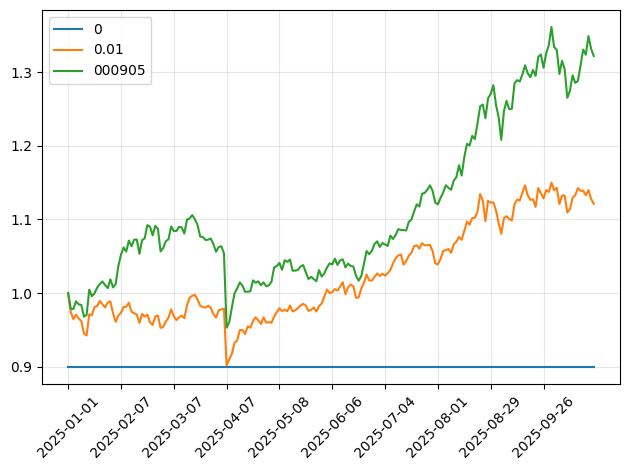

In [14]:
import matplotlib.pyplot as plt
import random

df_500 = pd.read_excel(f"{srcdir}/000905_SH.xlsx")
df_500.index = df_500["日期"].dt.strftime('%Y-%m-%d')
df_500.rename({"涨跌幅":"000905"},axis=1,inplace=True)

ret_df = pd.DataFrame(ret_dict,index=[f[:10] for f in files[1:]])
ret_df = ret_df.merge(df_500[["000905"]],left_index=True,right_index=True)
#ret_df = pd.DataFrame(ret_dict.items(),  # 键值对columns=["date", "value"]  # 列名你可以随便改).set_index("date")
temp = pd.DataFrame(0, index=["2025-01-01"], columns=ret_df.columns)
ret0_df = pd.concat([temp, ret_df], ignore_index=False)
ret_cum = (1 + ret0_df).cumprod()
ret_cum.insert(0,0,0.9) #选
ret_df.insert(0,0,0.9) #选

plt.plot(ret_cum,label=ret_cum.columns)
step = max(1, len(ret_cum) // 10)  # 最多显示10个刻度
plt.xticks(
    ticks=range(0, len(ret_cum), step),  # 按步长取刻度
    labels=ret_cum.index[::step],       # 对应标签
    rotation=45,                        # 标签倾斜45度（关键！）
    fontsize=10
)
plt.grid(alpha=0.3)  # 加网格更美观
plt.legend(loc='best')
plt.tight_layout()  # 自动适配布局，防止标签截断
ret_cum

,0.01,0.1,0.3,0.5,1,000905
2025-01-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2025-01-03,0.976067,0.977255,0.979247,0.980955,0.963789,0.978700
2025-01-06,0.971027,0.972742,0.978773,0.984860,0.959316,0.978602
2025-01-07,0.977445,0.977494,0.980600,0.986952,0.980287,0.988975
2025-01-08,0.970410,0.972782,0.976979,0.984996,0.979285,0.984822
...,...,...,...,...,...,...
2025-10-27,1.182091,1.224212,1.275119,1.312945,1.383929,1.330700
2025-10-28,1.175435,1.217909,1.269152,1.309302,1.384594,1.323780
2025-10-29,1.186193,1.227236,1.274053,1.313079,1.388594,1.349065
2025-10-30,1.174198,1.211372,1.257645,1.297874,1.373597,1.331931


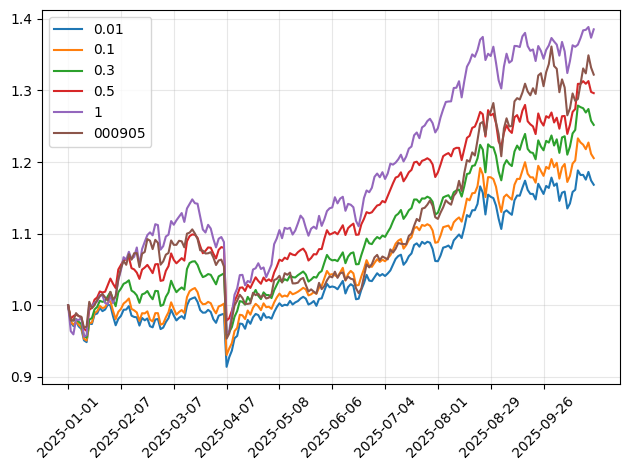

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
navdir =  "E:/SJTU/实习/国泰海通/barra因子/result/组合优化"
ret_cum = pd.read_excel(f"{navdir}/minmax_不同std_净值_完整因子部分正交【调方差】+ lam均衡.xlsx",index_col=0)
plt.plot(ret_cum,label=ret_cum.columns)
step = max(1, len(ret_cum) // 10)  # 最多显示10个刻度
plt.xticks(
    ticks=range(0, len(ret_cum), step),  # 按步长取刻度
    labels=ret_cum.index[::step],       # 对应标签
    rotation=45,                        # 标签倾斜45度（关键！）
    fontsize=10
)
plt.grid(alpha=0.3)  # 加网格更美观
plt.legend(loc='best')
plt.tight_layout()  # 自动适配布局，防止标签截断
ret_cum

In [15]:
#简单回测一下业绩
rf = 0.015
res = []
for i in range(1,ret_cum.shape[1]):
    port_nav = ret_cum.iloc[:,i]
    cum_ret = port_nav.iloc[-1] / port_nav.iloc[0] - 1
    ann_ret = (cum_ret + 1)**(252/len(port_nav)) - 1 #daily freq
    ann_vol = ret_df.iloc[:,i].std() * np.sqrt(252)
    sp = (ann_ret - rf) / ann_vol
    maxd = min(port_nav / port_nav.cummax()) - 1
    km = (ann_ret - rf) / abs(maxd) 
    result_dict = {
    '累计收益率': f'{float(cum_ret):.2%}',
    '年化收益率': f'{float(ann_ret):.2%}',
    '年化波动率': f'{float(ann_vol):.2%}',
    '夏普比率': f'{sp:.2f}',
    '最大回撤': f'{maxd:.2%}',
    '卡玛比率': f'{km:.2f}'}
    res.append(pd.Series(result_dict,name=ret_cum.columns[i]))

file_path = f"{spedir}/组合优化/minmax_不同std_净值.xlsx"
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    # 第一个表：ret_cum → Sheet1
    ret_cum.to_excel(writer, sheet_name='净值', index=True)
    
    # 第二个表：backtest → Sheet2（你要的）
    pd.concat(res,axis=1).to_excel(writer, sheet_name='回测结果', index=True, header=True)

print("Excel 保存成功！两个工作表都已写入 ✅")

Excel 保存成功！两个工作表都已写入 ✅


验证一下因子暴露二次标准化的可行性

In [ ]:
import os
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"
warnings.simplefilter('ignore')

std_lst = []
file = pd.read_pickle(f"{srcdir}/index_component_日频/000905.XSHG_20_26D_dict.pkl")
start_date = datetime(2025, 1, 1)
end_date = datetime(2026, 3, 25)
# 筛选符合条件的日期
filtered_dates = [date for date in file.keys() if start_date <= date <= end_date]
#mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_20_26D_dict.pkl")
for dt in filtered_dates:
    str_dt = dt.strftime("%Y-%m-%d")

    df_weight = file[dt]
    stamps = df_weight.index.tolist()
    stamps_rq = stamps#.str.replace('.SZ','.XSHE').str.replace('.SH','.XSHG')
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{str_dt}.pkl")
    #df_base = pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{str_dt}")

    df_905 = df_barra[df_barra["order_book_id"].isin(stamps_rq)]
    df = df_905.merge(df_weight,left_on="order_book_id",right_on="order_book_id")
    if len(df_905) != 500:
        print(str_dt,len(df_905))
    weights = df["weight"]
 
    #风格+行业因子均标准化【风格已经标准化一次，行业是原始暴露】
    style_cols = df_barra.columns[2:12]   
    industry_cols = df_barra.columns[13:44]
    df_neutralized = df_barra.copy()
    industry_id = df_barra[industry_cols].idxmax(axis=1)
    for style in style_cols:
        industry_means = df_barra.groupby(industry_id)[style].transform('mean')
        df_neutralized[style] = df_barra[style] - industry_means
    mean_905 = np.average(df.iloc[:,2:44], weights=weights, axis=0)
    df_neutralized.iloc[:,2:44] = df_neutralized.iloc[:,2:44] - mean_905
    
    #行业因子额外除以波动率
    # std_000 = df_neutralized.iloc[:, 13:44].std() 
    # df_neutralized.iloc[:, 13:44] = df_neutralized.iloc[:, 13:44] / std_000
    df_neutralized.to_pickle(f"{srcdir}/barra_data/000905标准化3_含行业/{str_dt}.pkl")
    print(f"dump {str_dt}")
        
#pd.concat(std_lst,axis=1).mean(axis=1)

dump 2025-01-02
dump 2025-01-03
dump 2025-01-06
dump 2025-01-07
dump 2025-01-08
dump 2025-01-09
dump 2025-01-10
dump 2025-01-13
dump 2025-01-14
dump 2025-01-15
dump 2025-01-16
dump 2025-01-17
dump 2025-01-20
dump 2025-01-21
dump 2025-01-22
dump 2025-01-23
dump 2025-01-24
dump 2025-01-27
dump 2025-02-05
dump 2025-02-06
dump 2025-02-07
dump 2025-02-10
dump 2025-02-11
dump 2025-02-12
dump 2025-02-13
dump 2025-02-14
dump 2025-02-17
dump 2025-02-18
dump 2025-02-19
dump 2025-02-20
dump 2025-02-21
dump 2025-02-24
dump 2025-02-25
dump 2025-02-26
dump 2025-02-27
dump 2025-02-28
dump 2025-03-03
dump 2025-03-04
dump 2025-03-05
dump 2025-03-06
dump 2025-03-07
dump 2025-03-10
dump 2025-03-11
dump 2025-03-12
dump 2025-03-13
dump 2025-03-14
dump 2025-03-17
dump 2025-03-18
dump 2025-03-19
dump 2025-03-20
dump 2025-03-21
dump 2025-03-24
dump 2025-03-25
dump 2025-03-26
dump 2025-03-27
dump 2025-03-28
dump 2025-03-31
dump 2025-04-01
dump 2025-04-02
dump 2025-04-03
dump 2025-04-07
dump 2025-04-08
dump 202

FileNotFoundError: [Errno 2] No such file or directory: 'E:/SJTU/实习/国泰海通/barra因子/data_base/barra_data/whole_mkt/2026-03-26.pkl'

In [19]:
df_weight.sum()
 

1.0

看一下因子收益率之间的相关性

In [4]:
from itertools import combinations
import os
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/fac_ret_cov"
files = os.listdir(srcdir)

corr_list = []
pairs = list(combinations(orth_order, 2))

for file in files:
    df_cov = pd.read_pickle(f"{srcdir}/{file}").loc[orth_order, orth_order]

    std = np.sqrt(np.diag(df_cov))
    corr = df_cov / np.outer(std, std)

    corr_dict = {}
    for i, j in pairs:
        corr_dict[(i, j)] = corr.loc[i, j]

    corr_list.append(corr_dict)

corr_df = pd.DataFrame(corr_list)
avg_corr = corr_df.mean()
res_s = avg_corr.sort_values(ascending=False)
res_s[abs(res_s)>0.3]

(non_linear_size, size)        0.510367
(beta, residual_volatility)    0.357558
(growth, size)                 0.340041
(earnings_yield, liquidity)   -0.308253
(book_to_price, growth)       -0.401809
(growth, leverage)            -0.441709
dtype: float64

管理人暴露的前置分析